Loading required package: nnet



GENERAL POLYNOMIAL FEATURE MODEL USING optim()
Model: y = w0 + w1*x + ... + w_(d-1)*x^(d-1) + e
Noise: e ~ N(0, |yi|)
Degree terms: 11 
Total raw points: 100 

Generated 200 experiments
Generated 400 experiments
Generated 600 experiments
Generated 800 experiments
Generated 1000 experiments
Generated 1200 experiments
Generated 1400 experiments
Generated 1600 experiments
Generated 1800 experiments
Generated 2000 experiments
Total experiments built: 2000 

Summary of true k*:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   2.000   5.541   7.000 190.000 


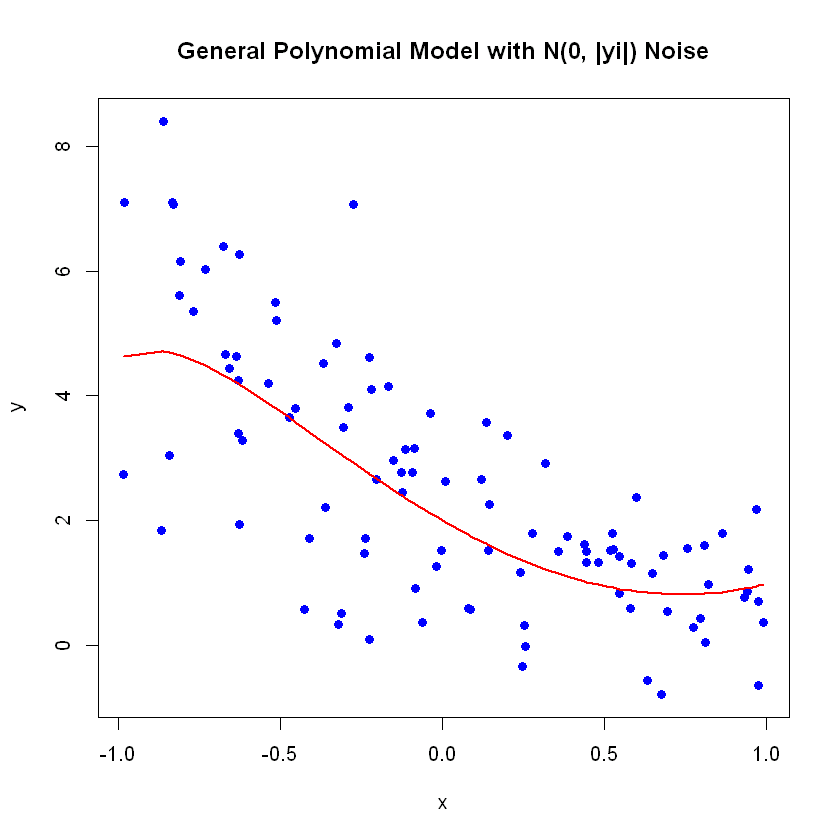

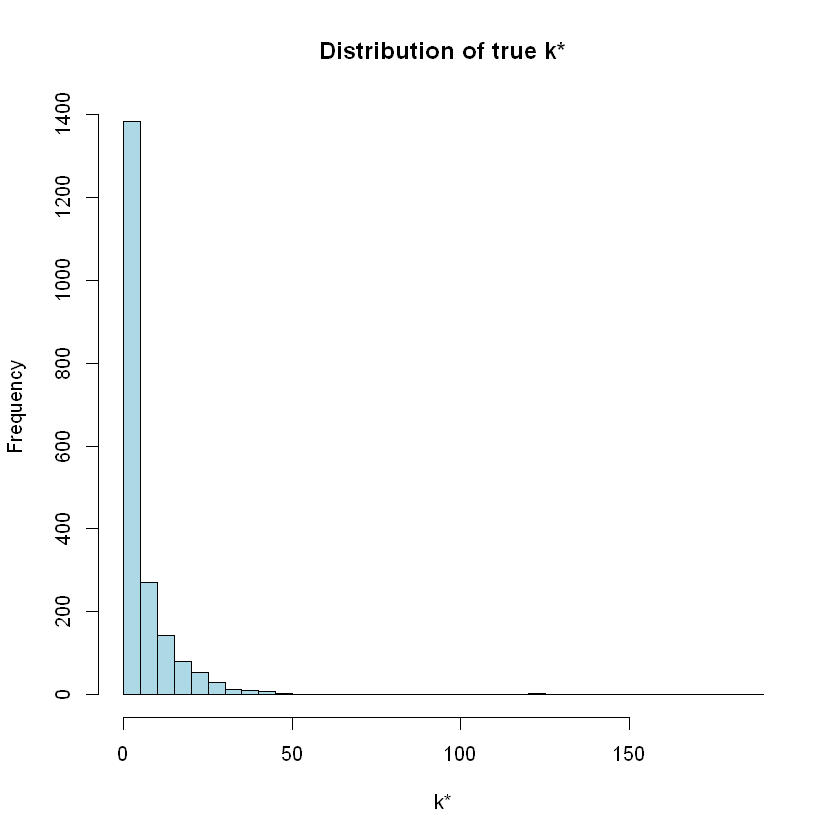

Total meta rows built: 2000 

Meta-train rows: 1600 
Meta-test rows : 400 

Mean CV RMSE raw: 14.25847 
Mean CV RMSE int: 13.36678 

Final Test RMSE raw: 11.74553 
Final Test RMSE int: 11.59752 
Final Test MAE int: 6.6125 


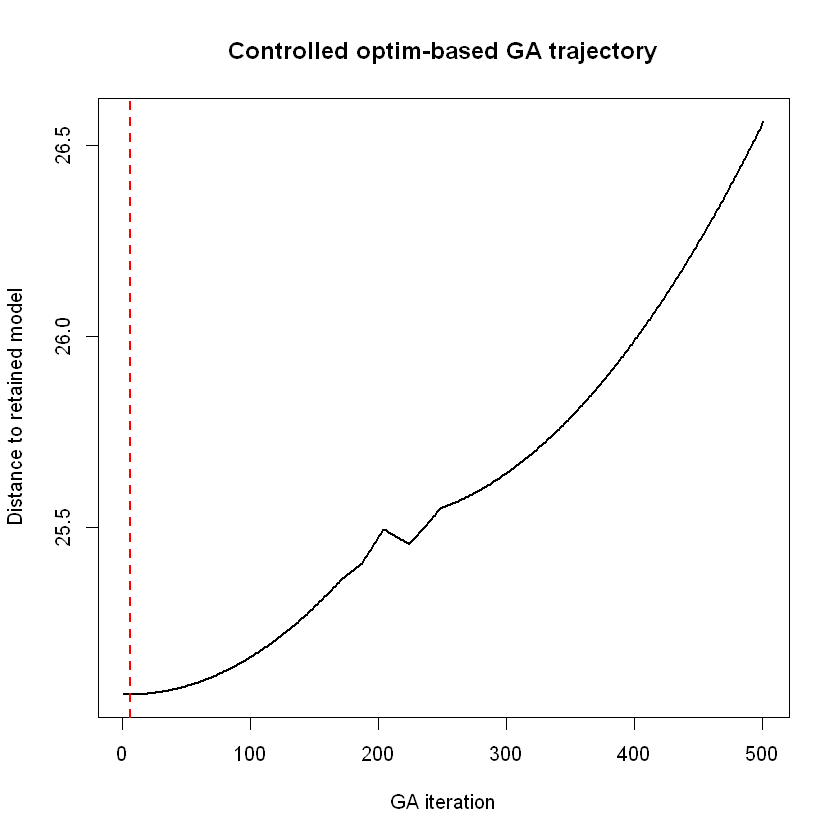

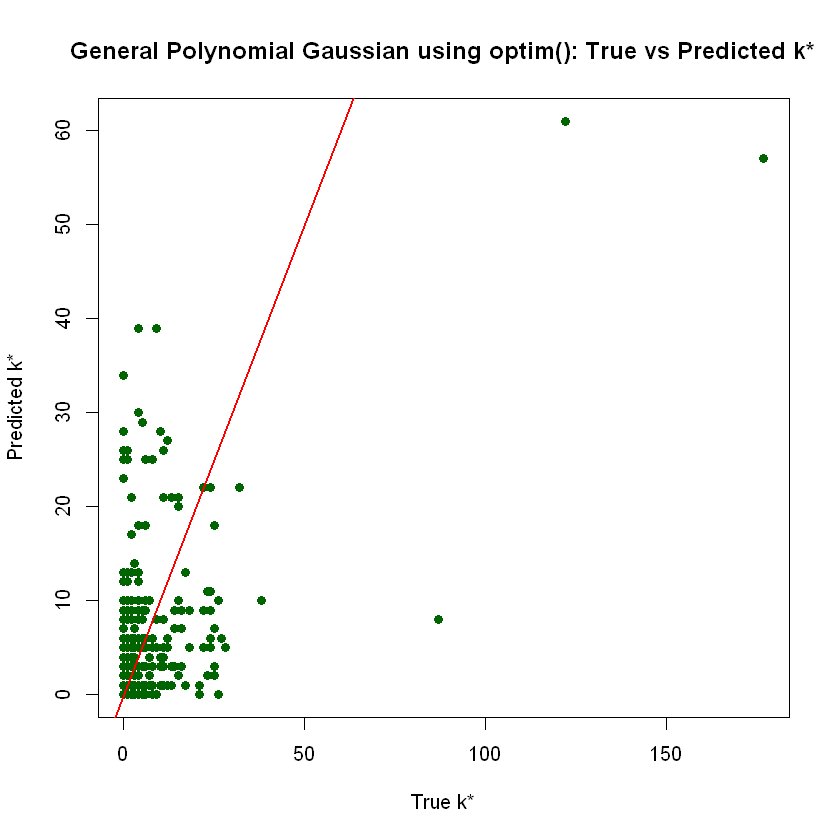

In [1]:
# GENERAL POLYNOMIAL MODEL USING optim()

# y = w0 + w1*x + w2*x^2 + ... + w_(d-1)*x^(d-1) + e
# e ~ N(0, |yi|)

# Controlled GA:
# optim() + L-BFGS-B
# T_GA = 500
# step_size = 0.001


set.seed(42)

if (!require(nnet)) {
  install.packages("nnet", repos = "https://cloud.r-project.org")
}
library(nnet)

safe_sd <- function(x) {
  if (length(x) <= 1) return(0)
  s <- sd(x)
  if (is.na(s) || is.nan(s) || is.infinite(s)) return(0)
  s
}

make_poly_design <- function(x, degree_terms = 11) {
  Phi <- sapply(0:(degree_terms - 1), function(k) x^k)
  colnames(Phi) <- paste0("x_power_", 0:(degree_terms - 1))
  as.matrix(Phi)
}

simulate_polynomial_gaussian_yi <- function(
    n = 100,
    degree_terms = 11,
    theta_true = c(2, -3, 1.5, 0.7, -0.4, 0.3,
  -0.2,0.15,-0.10,0.05,-0.02),
    x_min = -1,
    x_max = 1,
    min_sd = 0.001,
    seed = NULL
) {
  if (!is.null(seed)) set.seed(seed)

  if (length(theta_true) != degree_terms) {
    stop("theta_true length must match degree_terms")
  }

  x <- runif(n, x_min, x_max)

  Phi <- make_poly_design(x, degree_terms)

  y_true <- as.vector(Phi %*% theta_true)

  sigma_i <- sqrt(pmax(abs(y_true), min_sd))

  eps <- rnorm(
    n = n,
    mean = 0,
    sd = sigma_i
  )

  y_obs <- y_true + eps

  data.frame(
    x = x,
    y = y_obs,
    y_true = y_true,
    sigma_i = sigma_i
  )
}

standardize_xy <- function(x, y) {
  x_sd <- safe_sd(x)
  y_sd <- safe_sd(y)

  if (x_sd == 0) x_sd <- 1
  if (y_sd == 0) y_sd <- 1

  list(
    x = (x - mean(x)) / x_sd,
    y = (y - mean(y)) / y_sd
  )
}

mse_loss <- function(theta, Phi, Y) {
  pred <- as.vector(Phi %*% theta)
  mean((Y - pred)^2)
}

fit_optim_gd <- function(Phi, Y, theta_init = NULL, maxit = 1000) {
  if (is.null(theta_init)) {
    theta_init <- rep(0, ncol(Phi))
  }

  fit <- optim(
    par = theta_init,
    fn = mse_loss,
    Phi = Phi,
    Y = Y,
    method = "BFGS",
    control = list(maxit = maxit)
  )

  fit$par
}

ga_trajectory_optim <- function(
    theta_start,
    Phi_del,
    Y_del,
    T_GA = 500,
    step_size = 0.001
) {
  theta_now <- theta_start

  traj_theta <- matrix(
    NA,
    nrow = T_GA + 1,
    ncol = length(theta_start)
  )

  traj_theta[1, ] <- theta_now

  for (k in 1:T_GA) {
    fit <- optim(
      par = theta_now,
      fn = function(theta) {
        -mse_loss(theta, Phi_del, Y_del)
      },
      method = "L-BFGS-B",
      lower = theta_now - step_size,
      upper = theta_now + step_size,
      control = list(maxit = 1)
    )

    theta_now <- fit$par
    traj_theta[k + 1, ] <- theta_now
  }

  traj_theta
}

one_experiment_deleted_retained <- function(
    df,
    p_del,
    degree_terms = 11,
    T_GD = 1000,
    T_GA = 500,
    step_size = 0.001
) {
  x <- df$x
  y <- df$y
  n <- nrow(df)

  K_del <- max(1, floor(n * p_del))
  K_del <- min(K_del, n - 1)

  st <- standardize_xy(x, y)

  X <- st$x
  Y <- st$y

  Phi <- make_poly_design(X, degree_terms)

  theta_full <- fit_optim_gd(
    Phi = Phi,
    Y = Y,
    maxit = T_GD
  )

  del_idx <- sample(1:n, K_del, replace = FALSE)

  del_mask <- rep(FALSE, n)
  del_mask[del_idx] <- TRUE

  Phi_del <- Phi[del_mask, , drop = FALSE]
  Y_del <- Y[del_mask]

  Phi_ret <- Phi[!del_mask, , drop = FALSE]
  Y_ret <- Y[!del_mask]

  theta_ret <- fit_optim_gd(
    Phi = Phi_ret,
    Y = Y_ret,
    maxit = T_GD
  )

  traj_theta <- ga_trajectory_optim(
    theta_start = theta_full,
    Phi_del = Phi_del,
    Y_del = Y_del,
    T_GA = T_GA,
    step_size = step_size
  )

  dists <- rowSums(
    sweep(traj_theta, 2, theta_ret, "-")^2
  )

  k_star <- which.min(dists) - 1

  deleted_points <- as.matrix(df[del_mask, c("x", "y")])
  retained_points <- as.matrix(df[!del_mask, c("x", "y")])

  deleted_points <- deleted_points[order(deleted_points[, 1]), , drop = FALSE]
  retained_points <- retained_points[order(retained_points[, 1]), , drop = FALSE]

  list(
    deleted_points = deleted_points,
    retained_points = retained_points,
    k_star = as.numeric(k_star),
    K_del = K_del,
    p_del = p_del,
    dists = dists,
    theta_full = theta_full,
    theta_ret = theta_ret,
    traj_theta = traj_theta
  )
}

build_experiment_dataset <- function(
    df,
    n_experiments = 2000,
    degree_terms = 11,
    p_min = 0.01,
    p_max = 0.50,
    T_GD = 1000,
    T_GA = 500,
    step_size = 0.001
) {
  samples <- vector("list", n_experiments)

  for (i in 1:n_experiments) {
    p_now <- runif(1, min = p_min, max = p_max)

    samples[[i]] <- one_experiment_deleted_retained(
      df = df,
      p_del = p_now,
      degree_terms = degree_terms,
      T_GD = T_GD,
      T_GA = T_GA,
      step_size = step_size
    )

    if (i %% 200 == 0) {
      cat("Generated", i, "experiments\n")
    }
  }

  samples
}

embed_and_pool <- function(points_mat, W, b) {
  if (nrow(points_mat) == 0) {
    stop("Empty point set")
  }

  embedded <- sweep(points_mat %*% W, 2, b, "+")

  mean_pool <- colMeans(embedded)
  max_pool  <- apply(embedded, 2, max)
  min_pool  <- apply(embedded, 2, min)
  sd_pool   <- apply(embedded, 2, safe_sd)

  c(mean_pool, max_pool, min_pool, sd_pool)
}

build_pooled_feature_table <- function(
    samples,
    embed_dim = 16,
    total_raw_n = 100,
    seed = 42
) {
  set.seed(seed)

  W <- matrix(
    rnorm(2 * embed_dim, mean = 0, sd = 0.3),
    nrow = 2,
    ncol = embed_dim
  )

  b <- rnorm(embed_dim, mean = 0, sd = 0.05)

  rows <- vector("list", length(samples))

  for (i in seq_along(samples)) {
    s <- samples[[i]]

    del_vec <- embed_and_pool(s$deleted_points, W, b)
    ret_vec <- embed_and_pool(s$retained_points, W, b)

    row_i <- as.data.frame(as.list(c(del_vec, ret_vec)))

    names(row_i) <- c(
      paste0("del_mean_emb_", 1:embed_dim),
      paste0("del_max_emb_", 1:embed_dim),
      paste0("del_min_emb_", 1:embed_dim),
      paste0("del_sd_emb_", 1:embed_dim),
      paste0("ret_mean_emb_", 1:embed_dim),
      paste0("ret_max_emb_", 1:embed_dim),
      paste0("ret_min_emb_", 1:embed_dim),
      paste0("ret_sd_emb_", 1:embed_dim)
    )

    row_i$p_del <- s$p_del
    row_i$K_del <- s$K_del
    row_i$del_fraction <- s$K_del / total_raw_n
    row_i$target_k_star <- s$k_star

    rows[[i]] <- row_i
  }

  na.omit(do.call(rbind, rows))
}

scale_features_train <- function(df_features) {
  means <- sapply(df_features, mean)
  sds <- sapply(df_features, safe_sd)
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  list(data = scaled, means = means, sds = sds)
}

scale_features_apply <- function(df_features, means, sds) {
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  scaled
}

fit_best_nnet <- function(
    x_train_sc,
    y_train,
    hidden_units = 8,
    decay = 0.001,
    maxit = 1500,
    maxnwts = 20000,
    n_repeats = 5,
    seed = 42
) {
  best_fit <- NULL
  best_sse <- Inf

  for (r in 1:n_repeats) {
    set.seed(seed + r)

    fit_try <- try(
      nnet(
        x = x_train_sc,
        y = y_train,
        size = hidden_units,
        linout = TRUE,
        decay = decay,
        maxit = maxit,
        trace = FALSE,
        MaxNWts = maxnwts
      ),
      silent = TRUE
    )

    if (inherits(fit_try, "try-error")) next

    pred_train <- as.numeric(predict(fit_try, x_train_sc))
    sse <- sum((pred_train - y_train)^2)

    if (is.finite(sse) && sse < best_sse) {
      best_sse <- sse
      best_fit <- fit_try
    }
  }

  if (is.null(best_fit)) stop("All MLP fits failed.")
  best_fit
}

postprocess_khat <- function(pred_scaled, target_mean, target_sd, T_GA) {
  pred_raw <- pred_scaled * target_sd + target_mean
  pred_int <- round(pred_raw)
  pred_int <- pmax(0, pmin(T_GA, pred_int))

  list(pred_raw = pred_raw, pred_int = pred_int)
}

cv_mlp_regression <- function(
    meta_train,
    k_folds = 5,
    hidden_units = 8,
    T_GA = 500,
    seed = 42
) {
  set.seed(seed)

  n <- nrow(meta_train)
  fold_id <- sample(rep(1:k_folds, length.out = n))

  rmse_raw_vec <- c()
  rmse_int_vec <- c()

  feature_names <- setdiff(names(meta_train), "target_k_star")

  for (fold in 1:k_folds) {
    train_fold <- meta_train[fold_id != fold, ]
    valid_fold <- meta_train[fold_id == fold, ]

    x_train <- train_fold[, feature_names, drop = FALSE]
    y_train_raw <- train_fold$target_k_star

    x_valid <- valid_fold[, feature_names, drop = FALSE]
    y_valid <- valid_fold$target_k_star

    y_mean_fold <- mean(y_train_raw)
    y_sd_fold <- safe_sd(y_train_raw)

    if (y_sd_fold == 0) {
      y_sd_fold <- 1
    }

    y_train <- (y_train_raw - y_mean_fold) / y_sd_fold

    sc <- scale_features_train(x_train)

    x_train_sc <- as.matrix(sc$data)
    x_valid_sc <- as.matrix(
      scale_features_apply(x_valid, sc$means, sc$sds)
    )

    mlp_fit <- fit_best_nnet(
      x_train_sc = x_train_sc,
      y_train = y_train,
      hidden_units = hidden_units,
      seed = seed + 100 * fold
    )

    pred_scaled <- as.numeric(predict(mlp_fit, x_valid_sc))

    pred_out <- postprocess_khat(
      pred_scaled = pred_scaled,
      target_mean = y_mean_fold,
      target_sd = y_sd_fold,
      T_GA = T_GA
    )

    rmse_raw <- sqrt(mean((pred_out$pred_raw - y_valid)^2))
    rmse_int <- sqrt(mean((pred_out$pred_int - y_valid)^2))

    rmse_raw_vec <- c(rmse_raw_vec, rmse_raw)
    rmse_int_vec <- c(rmse_int_vec, rmse_int)
  }

  list(
    mean_rmse_raw = mean(rmse_raw_vec),
    mean_rmse_int = mean(rmse_int_vec)
  )
}

train_and_test_mlp <- function(
    meta_train,
    meta_test,
    hidden_units = 8,
    T_GA = 500,
    seed = 42
) {
  feature_names <- setdiff(names(meta_train), "target_k_star")

  target_mean <- mean(meta_train$target_k_star)
  target_sd <- safe_sd(meta_train$target_k_star)

  if (target_sd == 0) {
    target_sd <- 1
  }

  x_train <- meta_train[, feature_names, drop = FALSE]
  x_test <- meta_test[, feature_names, drop = FALSE]

  y_train_scaled <- (meta_train$target_k_star - target_mean) / target_sd
  y_test <- meta_test$target_k_star

  sc <- scale_features_train(x_train)

  x_train_sc <- as.matrix(sc$data)
  x_test_sc <- as.matrix(
    scale_features_apply(x_test, sc$means, sc$sds)
  )

  final_mlp <- fit_best_nnet(
    x_train_sc = x_train_sc,
    y_train = y_train_scaled,
    hidden_units = hidden_units,
    seed = seed
  )

  pred_scaled <- as.numeric(predict(final_mlp, x_test_sc))

  pred_out <- postprocess_khat(
    pred_scaled = pred_scaled,
    target_mean = target_mean,
    target_sd = target_sd,
    T_GA = T_GA
  )

  rmse_raw <- sqrt(mean((pred_out$pred_raw - y_test)^2))
  rmse_int <- sqrt(mean((pred_out$pred_int - y_test)^2))
  mae_int <- mean(abs(pred_out$pred_int - y_test))

  list(
    y_test = y_test,
    pred_int = pred_out$pred_int,
    rmse_raw = rmse_raw,
    rmse_int = rmse_int,
    mae_int = mae_int
  )
}

# MAIN
degree_terms <- 11

theta_true <- c(
  2,
  -3,
  1.5,
  0.7,
  -0.4,
  0.3,
  -0.2,
  0.15,
  -0.10,
  0.05,
  -0.02
)
base_df <- simulate_polynomial_gaussian_yi(
  n = 100,
  degree_terms = degree_terms,
  theta_true = theta_true,
  x_min = -1,
  x_max = 1,
  seed = 7
)

cat("GENERAL POLYNOMIAL FEATURE MODEL USING optim()\n")
cat("Model: y = w0 + w1*x + ... + w_(d-1)*x^(d-1) + e\n")
cat("Noise: e ~ N(0, |yi|)\n")
cat("Degree terms:", degree_terms, "\n")
cat("Total raw points:", nrow(base_df), "\n\n")

plot(
  base_df$x,
  base_df$y,
  pch = 16,
  col = "blue",
  xlab = "x",
  ylab = "y",
  main = "General Polynomial Model with N(0, |yi|) Noise"
)

ord <- order(base_df$x)
lines(base_df$x[ord], base_df$y_true[ord], col = "red", lwd = 2)

samples <- build_experiment_dataset(
  df = base_df,
  n_experiments = 2000,
  degree_terms = degree_terms,
  T_GA = 500,
  step_size = 0.001
)

cat("Total experiments built:", length(samples), "\n\n")

kstars <- sapply(samples, function(s) s$k_star)

cat("Summary of true k*:\n")
print(summary(kstars))

hist(
  kstars,
  breaks = 40,
  col = "lightblue",
  main = "Distribution of true k*",
  xlab = "k*"
)

plot(
  samples[[1]]$dists,
  type = "l",
  lwd = 2,
  xlab = "GA iteration",
  ylab = "Distance to retained model",
  main = "Controlled optim-based GA trajectory"
)

abline(
  v = samples[[1]]$k_star + 1,
  col = "red",
  lwd = 2,
  lty = 2
)

meta_all <- build_pooled_feature_table(
  samples = samples,
  embed_dim = 16,
  total_raw_n = nrow(base_df),
  seed = 42
)

cat("Total meta rows built:", nrow(meta_all), "\n\n")

set.seed(42)

idx_meta_train <- sample(
  seq_len(nrow(meta_all)),
  size = floor(0.8 * nrow(meta_all))
)

meta_train <- meta_all[idx_meta_train, ]
meta_test <- meta_all[-idx_meta_train, ]

cat("Meta-train rows:", nrow(meta_train), "\n")
cat("Meta-test rows :", nrow(meta_test), "\n\n")

cv_res <- cv_mlp_regression(
  meta_train = meta_train,
  hidden_units = 8,
  T_GA = 500
)

cat("Mean CV RMSE raw:", cv_res$mean_rmse_raw, "\n")
cat("Mean CV RMSE int:", cv_res$mean_rmse_int, "\n\n")

final_res <- train_and_test_mlp(
  meta_train = meta_train,
  meta_test = meta_test,
  hidden_units = 8,
  T_GA = 500
)

cat("Final Test RMSE raw:", final_res$rmse_raw, "\n")
cat("Final Test RMSE int:", final_res$rmse_int, "\n")
cat("Final Test MAE int:", final_res$mae_int, "\n")

plot(
  final_res$y_test,
  final_res$pred_int,
  pch = 16,
  col = "darkgreen",
  xlab = "True k*",
  ylab = "Predicted k*",
  main = "General Polynomial Gaussian using optim(): True vs Predicted k*"
)

abline(0, 1, col = "red", lwd = 2)
                 

GENERAL POLYNOMIAL FEATURE MODEL USING optim()
Model: y = w0 + w1*x + ... + w_(d-1)*x^(d-1) + e
Noise: e ~ L(0, |yi|)
Degree terms: 11 
Total raw points: 100 

Generated 200 experiments
Generated 400 experiments
Generated 600 experiments
Generated 800 experiments
Generated 1000 experiments
Generated 1200 experiments
Generated 1400 experiments
Generated 1600 experiments
Generated 1800 experiments
Generated 2000 experiments
Total experiments built: 2000 

Summary of true k*:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   1.000   6.493   9.000 500.000 


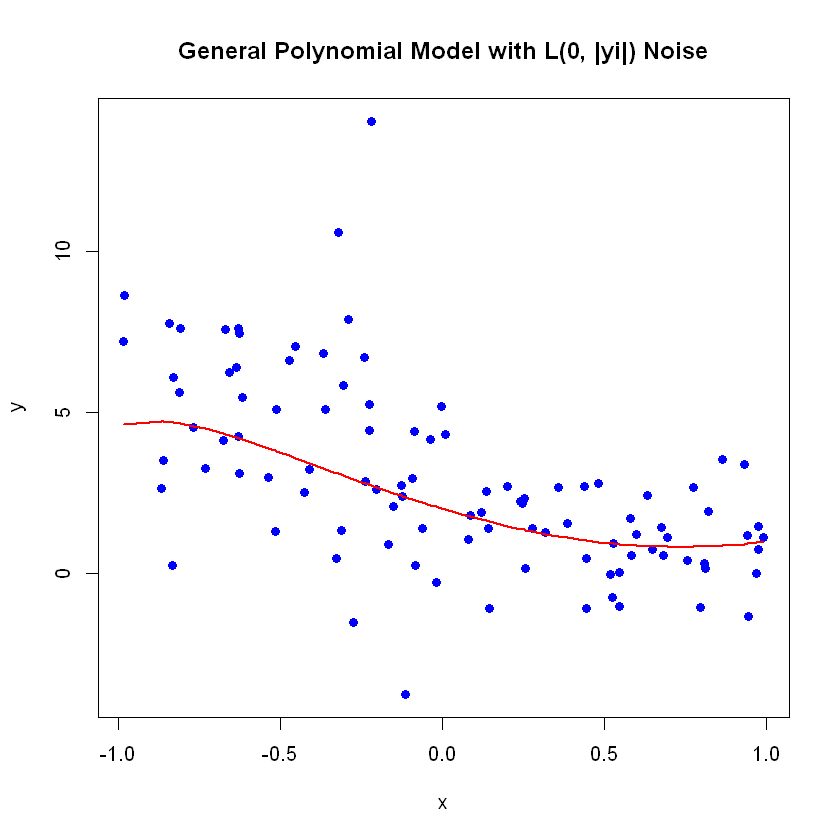

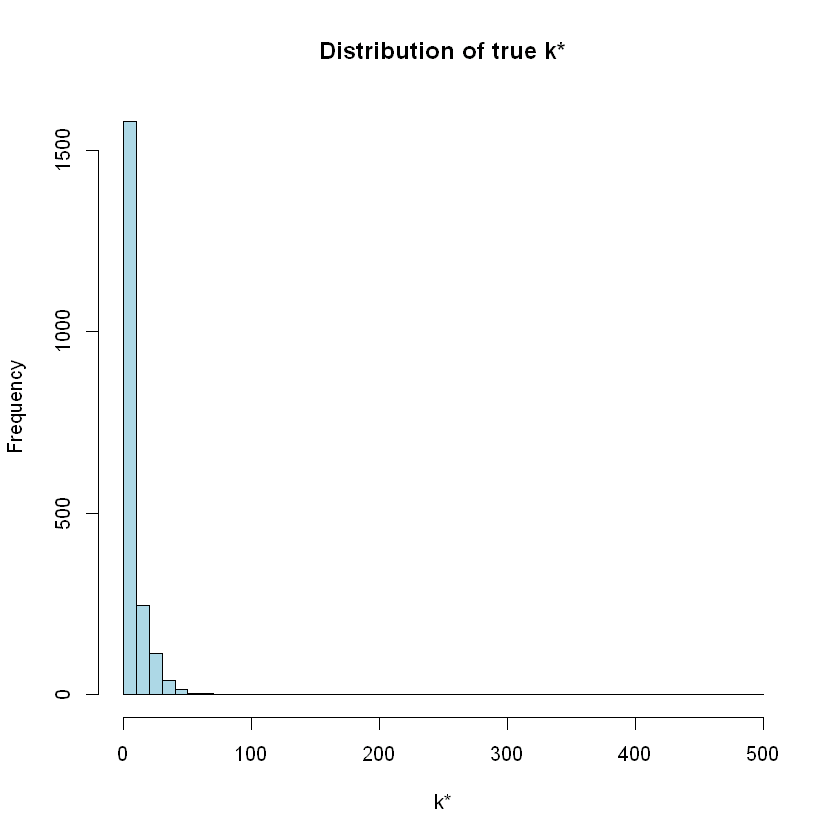

Total meta rows built: 2000 

Meta-train rows: 1600 
Meta-test rows : 400 

Mean CV RMSE raw: 21.88548 
Mean CV RMSE int: 19.60874 

Final Test RMSE raw: 28.49321 
Final Test RMSE int: 28.26146 
Final Test MAE int: 8.99 


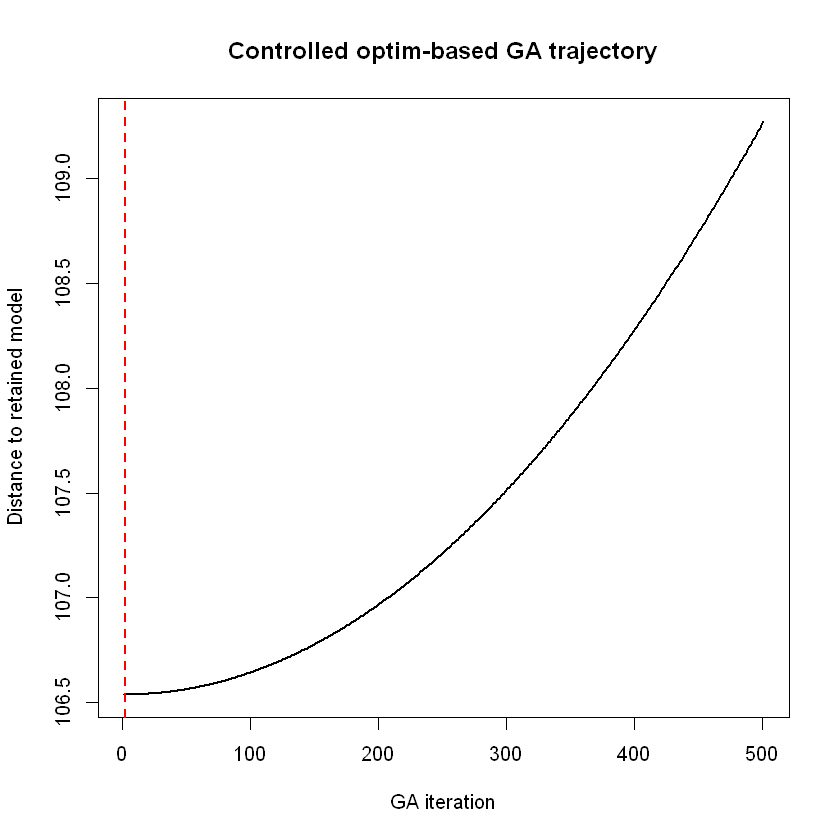

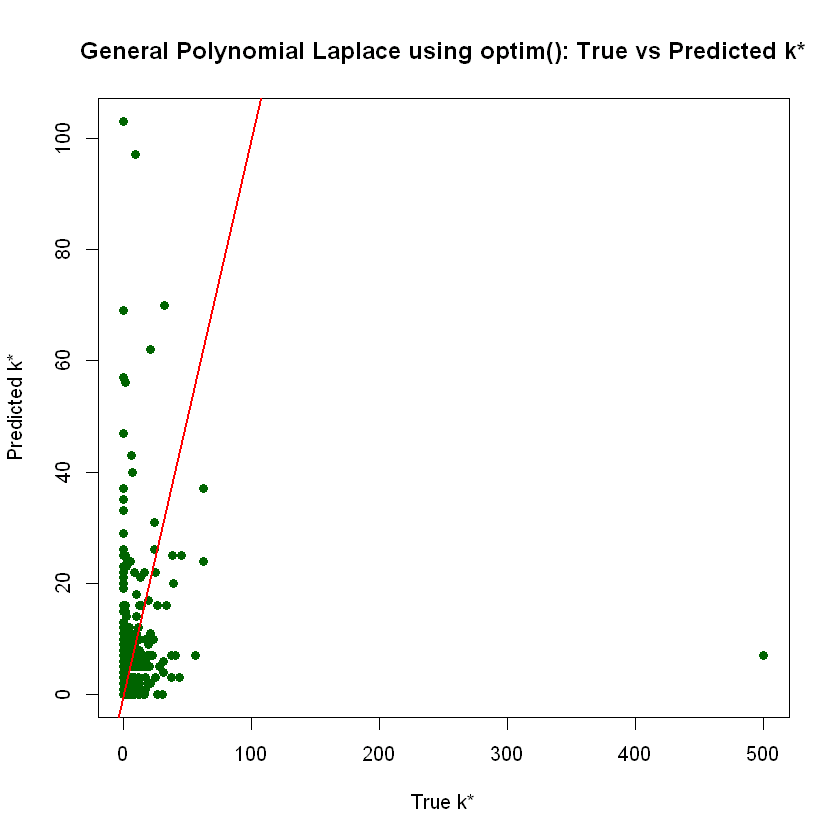

In [3]:
# GENERAL POLYNOMIAL MODEL USING optim()
#
# y = w0 + w1*x + w2*x^2 + ... + w_(d-1)*x^(d-1) + e
# e ~ L(0, |yi|)
#
# Controlled GA:
# optim() + L-BFGS-B
# T_GA = 500
# step_size = 0.001


set.seed(42)

if (!require(nnet)) {
  install.packages("nnet", repos = "https://cloud.r-project.org")
}
library(nnet)

safe_sd <- function(x) {
  if (length(x) <= 1) return(0)
  s <- sd(x)
  if (is.na(s) || is.nan(s) || is.infinite(s)) return(0)
  s
}

rlaplace <- function(n, location = 0, scale = 1) {
  if (length(scale) == 1) {
    scale <- rep(scale, n)
  }

  u <- runif(n, -0.5, 0.5)

  location - scale * sign(u) * log(1 - 2 * abs(u))
}

make_poly_design <- function(x, degree_terms = 5) {
  Phi <- sapply(0:(degree_terms - 1), function(k) x^k)
  colnames(Phi) <- paste0("x_power_", 0:(degree_terms - 1))
  as.matrix(Phi)
}

simulate_polynomial_laplace_yi <- function(
    n = 100,
    degree_terms = 7,
    theta_true = c(2, -3, 1.5, 0.7, -0.4,0.3,
  -0.2,0.15,-0.10,0.05,-0.02),
    x_min = -1,
    x_max = 1,
    min_scale = 0.001,
    seed = NULL
) {
  if (!is.null(seed)) set.seed(seed)

  if (length(theta_true) != degree_terms) {
    stop("theta_true length must match degree_terms")
  }

  x <- runif(n, x_min, x_max)

  Phi <- make_poly_design(x, degree_terms)

  y_true <- as.vector(Phi %*% theta_true)

  scale_i <- pmax(abs(y_true), min_scale)

  eps <- rlaplace(
    n = n,
    location = 0,
    scale = scale_i
  )

  y_obs <- y_true + eps

  data.frame(
    x = x,
    y = y_obs,
    y_true = y_true,
    scale_i = scale_i
  )
}

standardize_xy <- function(x, y) {
  x_sd <- safe_sd(x)
  y_sd <- safe_sd(y)

  if (x_sd == 0) x_sd <- 1
  if (y_sd == 0) y_sd <- 1

  list(
    x = (x - mean(x)) / x_sd,
    y = (y - mean(y)) / y_sd
  )
}

mse_loss <- function(theta, Phi, Y) {
  pred <- as.vector(Phi %*% theta)
  mean((Y - pred)^2)
}

fit_optim_gd <- function(Phi, Y, theta_init = NULL, maxit = 1000) {
  if (is.null(theta_init)) {
    theta_init <- rep(0, ncol(Phi))
  }

  fit <- optim(
    par = theta_init,
    fn = mse_loss,
    Phi = Phi,
    Y = Y,
    method = "BFGS",
    control = list(maxit = maxit)
  )

  fit$par
}

ga_trajectory_optim <- function(
    theta_start,
    Phi_del,
    Y_del,
    T_GA = 500,
    step_size = 0.001
) {
  theta_now <- theta_start

  traj_theta <- matrix(
    NA,
    nrow = T_GA + 1,
    ncol = length(theta_start)
  )

  traj_theta[1, ] <- theta_now

  for (k in 1:T_GA) {
    fit <- optim(
      par = theta_now,
      fn = function(theta) {
        -mse_loss(theta, Phi_del, Y_del)
      },
      method = "L-BFGS-B",
      lower = theta_now - step_size,
      upper = theta_now + step_size,
      control = list(maxit = 1)
    )

    theta_now <- fit$par
    traj_theta[k + 1, ] <- theta_now
  }

  traj_theta
}

one_experiment_deleted_retained <- function(
    df,
    p_del,
    degree_terms = 11,
    T_GD = 1000,
    T_GA = 500,
    step_size = 0.001
) {
  x <- df$x
  y <- df$y
  n <- nrow(df)

  K_del <- max(1, floor(n * p_del))
  K_del <- min(K_del, n - 1)

  st <- standardize_xy(x, y)

  X <- st$x
  Y <- st$y

  Phi <- make_poly_design(X, degree_terms)

  theta_full <- fit_optim_gd(
    Phi = Phi,
    Y = Y,
    maxit = T_GD
  )

  del_idx <- sample(1:n, K_del, replace = FALSE)

  del_mask <- rep(FALSE, n)
  del_mask[del_idx] <- TRUE

  Phi_del <- Phi[del_mask, , drop = FALSE]
  Y_del <- Y[del_mask]

  Phi_ret <- Phi[!del_mask, , drop = FALSE]
  Y_ret <- Y[!del_mask]

  theta_ret <- fit_optim_gd(
    Phi = Phi_ret,
    Y = Y_ret,
    maxit = T_GD
  )

  traj_theta <- ga_trajectory_optim(
    theta_start = theta_full,
    Phi_del = Phi_del,
    Y_del = Y_del,
    T_GA = T_GA,
    step_size = step_size
  )

  dists <- rowSums(
    sweep(traj_theta, 2, theta_ret, "-")^2
  )

  k_star <- which.min(dists) - 1

  deleted_points <- as.matrix(df[del_mask, c("x", "y")])
  retained_points <- as.matrix(df[!del_mask, c("x", "y")])

  deleted_points <- deleted_points[order(deleted_points[, 1]), , drop = FALSE]
  retained_points <- retained_points[order(retained_points[, 1]), , drop = FALSE]

  list(
    deleted_points = deleted_points,
    retained_points = retained_points,
    k_star = as.numeric(k_star),
    K_del = K_del,
    p_del = p_del,
    dists = dists,
    theta_full = theta_full,
    theta_ret = theta_ret,
    traj_theta = traj_theta
  )
}

build_experiment_dataset <- function(
    df,
    n_experiments = 2000,
    degree_terms = 11,
    p_min = 0.01,
    p_max = 0.50,
    T_GD = 1000,
    T_GA = 500,
    step_size = 0.001
) {
  samples <- vector("list", n_experiments)

  for (i in 1:n_experiments) {
    p_now <- runif(1, min = p_min, max = p_max)

    samples[[i]] <- one_experiment_deleted_retained(
      df = df,
      p_del = p_now,
      degree_terms = degree_terms,
      T_GD = T_GD,
      T_GA = T_GA,
      step_size = step_size
    )

    if (i %% 200 == 0) {
      cat("Generated", i, "experiments\n")
    }
  }

  samples
}

embed_and_pool <- function(points_mat, W, b) {
  if (nrow(points_mat) == 0) {
    stop("Empty point set")
  }

  embedded <- sweep(points_mat %*% W, 2, b, "+")

  mean_pool <- colMeans(embedded)
  max_pool  <- apply(embedded, 2, max)
  min_pool  <- apply(embedded, 2, min)
  sd_pool   <- apply(embedded, 2, safe_sd)

  c(mean_pool, max_pool, min_pool, sd_pool)
}

build_pooled_feature_table <- function(
    samples,
    embed_dim = 16,
    total_raw_n = 100,
    seed = 42
) {
  set.seed(seed)

  W <- matrix(
    rnorm(2 * embed_dim, mean = 0, sd = 0.3),
    nrow = 2,
    ncol = embed_dim
  )

  b <- rnorm(embed_dim, mean = 0, sd = 0.05)

  rows <- vector("list", length(samples))

  for (i in seq_along(samples)) {
    s <- samples[[i]]

    del_vec <- embed_and_pool(s$deleted_points, W, b)
    ret_vec <- embed_and_pool(s$retained_points, W, b)

    row_i <- as.data.frame(as.list(c(del_vec, ret_vec)))

    names(row_i) <- c(
      paste0("del_mean_emb_", 1:embed_dim),
      paste0("del_max_emb_", 1:embed_dim),
      paste0("del_min_emb_", 1:embed_dim),
      paste0("del_sd_emb_", 1:embed_dim),
      paste0("ret_mean_emb_", 1:embed_dim),
      paste0("ret_max_emb_", 1:embed_dim),
      paste0("ret_min_emb_", 1:embed_dim),
      paste0("ret_sd_emb_", 1:embed_dim)
    )

    row_i$p_del <- s$p_del
    row_i$K_del <- s$K_del
    row_i$del_fraction <- s$K_del / total_raw_n
    row_i$target_k_star <- s$k_star

    rows[[i]] <- row_i
  }

  na.omit(do.call(rbind, rows))
}

scale_features_train <- function(df_features) {
  means <- sapply(df_features, mean)
  sds <- sapply(df_features, safe_sd)
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  list(data = scaled, means = means, sds = sds)
}

scale_features_apply <- function(df_features, means, sds) {
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  scaled
}

fit_best_nnet <- function(
    x_train_sc,
    y_train,
    hidden_units = 8,
    decay = 0.001,
    maxit = 1500,
    maxnwts = 20000,
    n_repeats = 5,
    seed = 42
) {
  best_fit <- NULL
  best_sse <- Inf

  for (r in 1:n_repeats) {
    set.seed(seed + r)

    fit_try <- try(
      nnet(
        x = x_train_sc,
        y = y_train,
        size = hidden_units,
        linout = TRUE,
        decay = decay,
        maxit = maxit,
        trace = FALSE,
        MaxNWts = maxnwts
      ),
      silent = TRUE
    )

    if (inherits(fit_try, "try-error")) next

    pred_train <- as.numeric(predict(fit_try, x_train_sc))
    sse <- sum((pred_train - y_train)^2)

    if (is.finite(sse) && sse < best_sse) {
      best_sse <- sse
      best_fit <- fit_try
    }
  }

  if (is.null(best_fit)) stop("All MLP fits failed.")
  best_fit
}

postprocess_khat <- function(pred_scaled, target_mean, target_sd, T_GA) {
  pred_raw <- pred_scaled * target_sd + target_mean
  pred_int <- round(pred_raw)
  pred_int <- pmax(0, pmin(T_GA, pred_int))

  list(pred_raw = pred_raw, pred_int = pred_int)
}

cv_mlp_regression <- function(
    meta_train,
    k_folds = 5,
    hidden_units = 8,
    T_GA = 500,
    seed = 42
) {
  set.seed(seed)

  n <- nrow(meta_train)
  fold_id <- sample(rep(1:k_folds, length.out = n))

  rmse_raw_vec <- c()
  rmse_int_vec <- c()

  feature_names <- setdiff(names(meta_train), "target_k_star")

  for (fold in 1:k_folds) {
    train_fold <- meta_train[fold_id != fold, ]
    valid_fold <- meta_train[fold_id == fold, ]

    x_train <- train_fold[, feature_names, drop = FALSE]
    y_train_raw <- train_fold$target_k_star

    x_valid <- valid_fold[, feature_names, drop = FALSE]
    y_valid <- valid_fold$target_k_star

    y_mean_fold <- mean(y_train_raw)
    y_sd_fold <- safe_sd(y_train_raw)

    if (y_sd_fold == 0) {
      y_sd_fold <- 1
    }

    y_train <- (y_train_raw - y_mean_fold) / y_sd_fold

    sc <- scale_features_train(x_train)

    x_train_sc <- as.matrix(sc$data)
    x_valid_sc <- as.matrix(
      scale_features_apply(x_valid, sc$means, sc$sds)
    )

    mlp_fit <- fit_best_nnet(
      x_train_sc = x_train_sc,
      y_train = y_train,
      hidden_units = hidden_units,
      seed = seed + 100 * fold
    )

    pred_scaled <- as.numeric(predict(mlp_fit, x_valid_sc))

    pred_out <- postprocess_khat(
      pred_scaled = pred_scaled,
      target_mean = y_mean_fold,
      target_sd = y_sd_fold,
      T_GA = T_GA
    )

    rmse_raw <- sqrt(mean((pred_out$pred_raw - y_valid)^2))
    rmse_int <- sqrt(mean((pred_out$pred_int - y_valid)^2))

    rmse_raw_vec <- c(rmse_raw_vec, rmse_raw)
    rmse_int_vec <- c(rmse_int_vec, rmse_int)
  }

  list(
    mean_rmse_raw = mean(rmse_raw_vec),
    mean_rmse_int = mean(rmse_int_vec)
  )
}

train_and_test_mlp <- function(
    meta_train,
    meta_test,
    hidden_units = 8,
    T_GA = 500,
    seed = 42
) {
  feature_names <- setdiff(names(meta_train), "target_k_star")

  target_mean <- mean(meta_train$target_k_star)
  target_sd <- safe_sd(meta_train$target_k_star)

  if (target_sd == 0) {
    target_sd <- 1
  }

  x_train <- meta_train[, feature_names, drop = FALSE]
  x_test <- meta_test[, feature_names, drop = FALSE]

  y_train_scaled <- (meta_train$target_k_star - target_mean) / target_sd
  y_test <- meta_test$target_k_star

  sc <- scale_features_train(x_train)

  x_train_sc <- as.matrix(sc$data)
  x_test_sc <- as.matrix(
    scale_features_apply(x_test, sc$means, sc$sds)
  )

  final_mlp <- fit_best_nnet(
    x_train_sc = x_train_sc,
    y_train = y_train_scaled,
    hidden_units = hidden_units,
    seed = seed
  )

  pred_scaled <- as.numeric(predict(final_mlp, x_test_sc))

  pred_out <- postprocess_khat(
    pred_scaled = pred_scaled,
    target_mean = target_mean,
    target_sd = target_sd,
    T_GA = T_GA
  )

  rmse_raw <- sqrt(mean((pred_out$pred_raw - y_test)^2))
  rmse_int <- sqrt(mean((pred_out$pred_int - y_test)^2))
  mae_int <- mean(abs(pred_out$pred_int - y_test))

  list(
    y_test = y_test,
    pred_int = pred_out$pred_int,
    rmse_raw = rmse_raw,
    rmse_int = rmse_int,
    mae_int = mae_int
  )
}

# MAIN
degree_terms <- 11

theta_true <- c(2, -3, 1.5, 0.7, -0.4,0.3,
  -0.2,0.15,-0.10,0.05,-0.02)

base_df <- simulate_polynomial_laplace_yi(
  n = 100,
  degree_terms = degree_terms,
  theta_true = theta_true,
  x_min = -1,
  x_max = 1,
  seed = 7
)

cat("GENERAL POLYNOMIAL FEATURE MODEL USING optim()\n")
cat("Model: y = w0 + w1*x + ... + w_(d-1)*x^(d-1) + e\n")
cat("Noise: e ~ L(0, |yi|)\n")
cat("Degree terms:", degree_terms, "\n")
cat("Total raw points:", nrow(base_df), "\n\n")

plot(
  base_df$x,
  base_df$y,
  pch = 16,
  col = "blue",
  xlab = "x",
  ylab = "y",
  main = "General Polynomial Model with L(0, |yi|) Noise"
)

ord <- order(base_df$x)
lines(base_df$x[ord], base_df$y_true[ord], col = "red", lwd = 2)

samples <- build_experiment_dataset(
  df = base_df,
  n_experiments = 2000,
  degree_terms = degree_terms,
  T_GA = 500,
  step_size = 0.001
)

cat("Total experiments built:", length(samples), "\n\n")

kstars <- sapply(samples, function(s) s$k_star)

cat("Summary of true k*:\n")
print(summary(kstars))

hist(
  kstars,
  breaks = 40,
  col = "lightblue",
  main = "Distribution of true k*",
  xlab = "k*"
)

plot(
  samples[[1]]$dists,
  type = "l",
  lwd = 2,
  xlab = "GA iteration",
  ylab = "Distance to retained model",
  main = "Controlled optim-based GA trajectory"
)

abline(
  v = samples[[1]]$k_star + 1,
  col = "red",
  lwd = 2,
  lty = 2
)

meta_all <- build_pooled_feature_table(
  samples = samples,
  embed_dim = 16,
  total_raw_n = nrow(base_df),
  seed = 42
)

cat("Total meta rows built:", nrow(meta_all), "\n\n")

set.seed(42)

idx_meta_train <- sample(
  seq_len(nrow(meta_all)),
  size = floor(0.8 * nrow(meta_all))
)

meta_train <- meta_all[idx_meta_train, ]
meta_test <- meta_all[-idx_meta_train, ]

cat("Meta-train rows:", nrow(meta_train), "\n")
cat("Meta-test rows :", nrow(meta_test), "\n\n")

cv_res <- cv_mlp_regression(
  meta_train = meta_train,
  hidden_units = 8,
  T_GA = 500
)

cat("Mean CV RMSE raw:", cv_res$mean_rmse_raw, "\n")
cat("Mean CV RMSE int:", cv_res$mean_rmse_int, "\n\n")

final_res <- train_and_test_mlp(
  meta_train = meta_train,
  meta_test = meta_test,
  hidden_units = 8,
  T_GA = 500
)

cat("Final Test RMSE raw:", final_res$rmse_raw, "\n")
cat("Final Test RMSE int:", final_res$rmse_int, "\n")
cat("Final Test MAE int:", final_res$mae_int, "\n")

plot(
  final_res$y_test,
  final_res$pred_int,
  pch = 16,
  col = "darkgreen",
  xlab = "True k*",
  ylab = "Predicted k*",
  main = "General Polynomial Laplace using optim(): True vs Predicted k*"
)

abline(0, 1, col = "red", lwd = 2)

GENERAL POLYNOMIAL FEATURE MODEL USING optim()
Model: y = w0 + w1*x + ... + w_(d-1)*x^(d-1) + e
Noise: e ~ L(0, |yi|)
Degree terms: 5 
Total raw points: 100 

Generated 200 experiments
Generated 400 experiments
Generated 600 experiments
Generated 800 experiments
Generated 1000 experiments
Generated 1200 experiments
Generated 1400 experiments
Generated 1600 experiments
Generated 1800 experiments
Generated 2000 experiments
Total experiments built: 2000 

Summary of true k*:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    2.00   11.00   17.49   25.00  165.00 


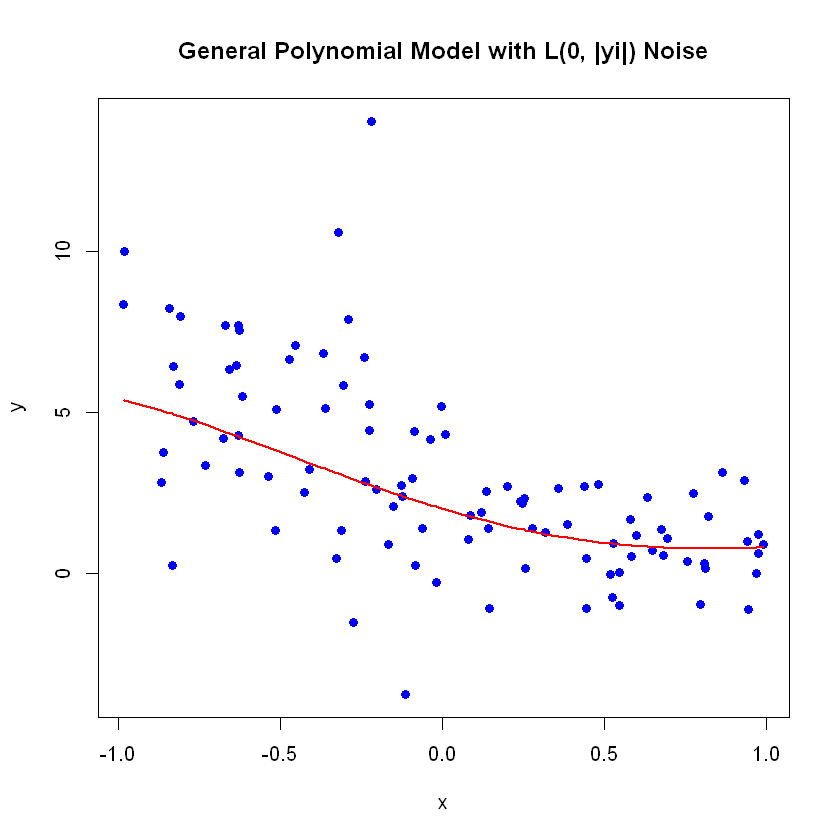

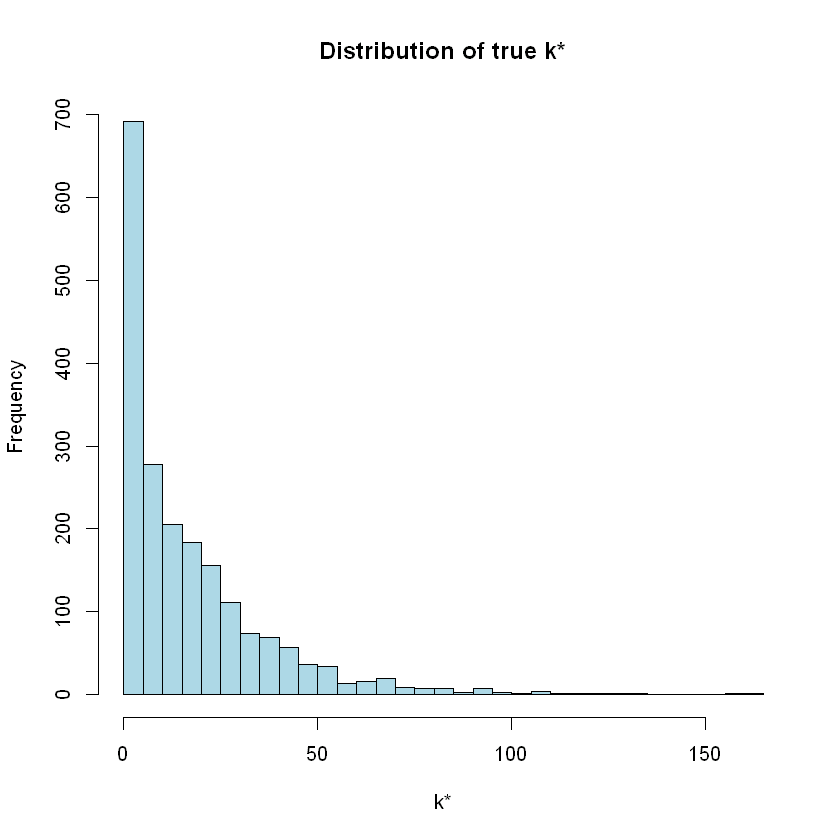

Total meta rows built: 2000 

Meta-train rows: 1600 
Meta-test rows : 400 

Mean CV RMSE raw: 23.7705 
Mean CV RMSE int: 22.33952 

Final Test RMSE raw: 19.75609 
Final Test RMSE int: 18.91891 
Final Test MAE int: 13.98 


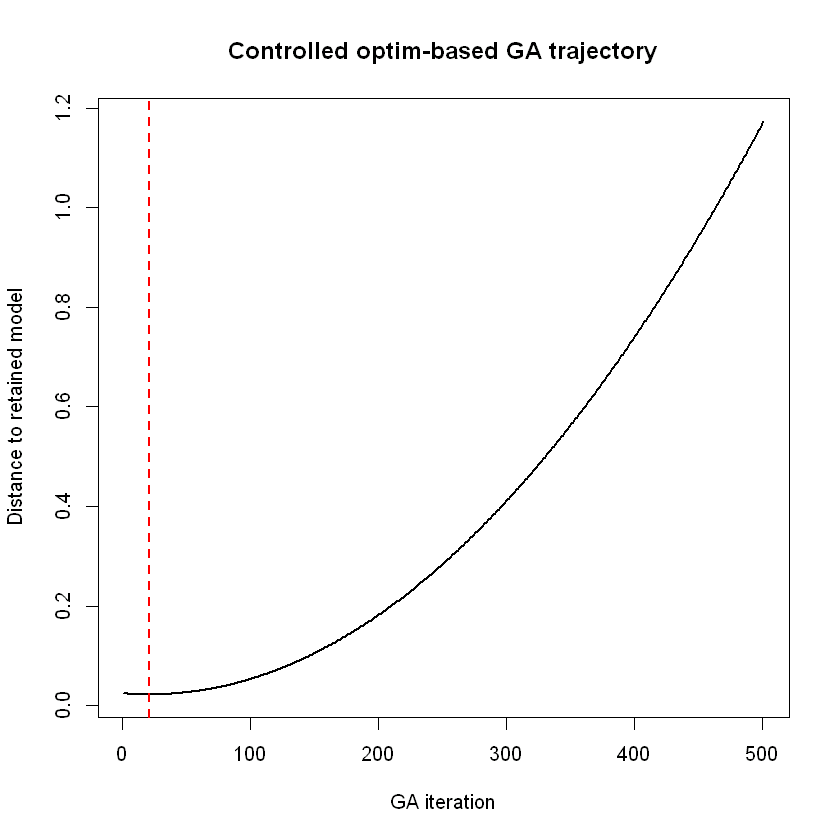

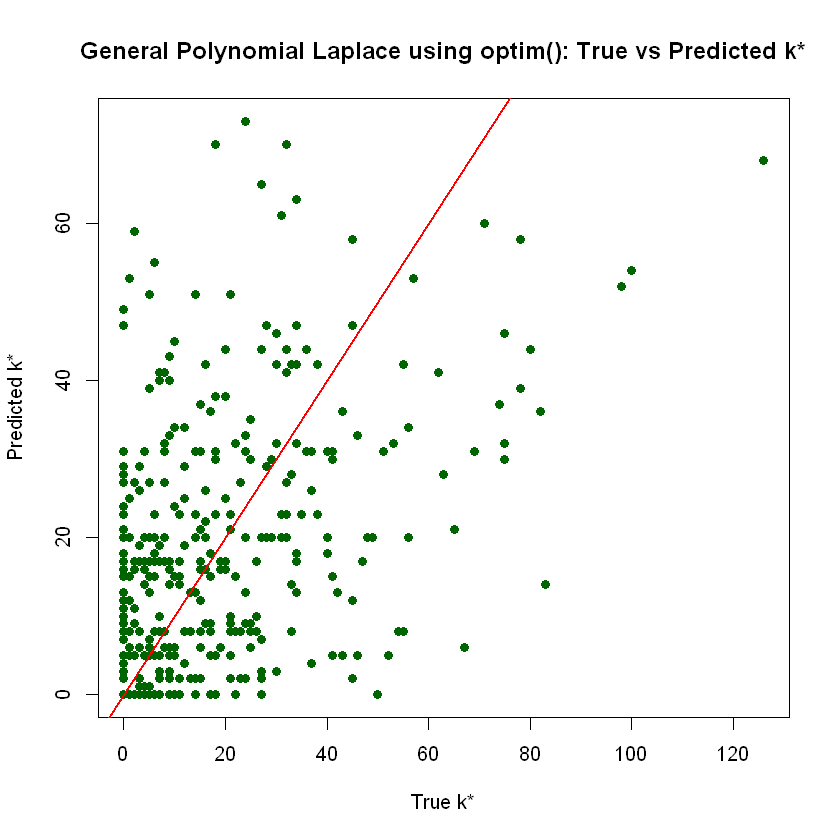

In [5]:
# GENERAL POLYNOMIAL MODEL USING optim()

# y = w0 + w1*x + w2*x^2 + ... + w_(d-1)*x^(d-1) + e
# e ~ L(0, |yi|)

# Controlled GA:
# optim() + L-BFGS-B
# T_GA = 500
# step_size = 0.001


set.seed(42)

if (!require(nnet)) {
  install.packages("nnet", repos = "https://cloud.r-project.org")
}
library(nnet)

safe_sd <- function(x) {
  if (length(x) <= 1) return(0)
  s <- sd(x)
  if (is.na(s) || is.nan(s) || is.infinite(s)) return(0)
  s
}

rlaplace <- function(n, location = 0, scale = 1) {
  if (length(scale) == 1) {
    scale <- rep(scale, n)
  }

  u <- runif(n, -0.5, 0.5)

  location - scale * sign(u) * log(1 - 2 * abs(u))
}

make_poly_design <- function(x, degree_terms = 5) {
  Phi <- sapply(0:(degree_terms - 1), function(k) x^k)
  colnames(Phi) <- paste0("x_power_", 0:(degree_terms - 1))
  as.matrix(Phi)
}

simulate_polynomial_laplace_yi <- function(
    n = 100,
    degree_terms = 5,
    theta_true = c(2, -3, 1.5, 0.7, -0.4),
    x_min = -1,
    x_max = 1,
    min_scale = 0.001,
    seed = NULL
) {
  if (!is.null(seed)) set.seed(seed)

  if (length(theta_true) != degree_terms) {
    stop("theta_true length must match degree_terms")
  }

  x <- runif(n, x_min, x_max)

  Phi <- make_poly_design(x, degree_terms)

  y_true <- as.vector(Phi %*% theta_true)

  scale_i <- pmax(abs(y_true), min_scale)

  eps <- rlaplace(
    n = n,
    location = 0,
    scale = scale_i
  )

  y_obs <- y_true + eps

  data.frame(
    x = x,
    y = y_obs,
    y_true = y_true,
    scale_i = scale_i
  )
}

standardize_xy <- function(x, y) {
  x_sd <- safe_sd(x)
  y_sd <- safe_sd(y)

  if (x_sd == 0) x_sd <- 1
  if (y_sd == 0) y_sd <- 1

  list(
    x = (x - mean(x)) / x_sd,
    y = (y - mean(y)) / y_sd
  )
}

mse_loss <- function(theta, Phi, Y) {
  pred <- as.vector(Phi %*% theta)
  mean((Y - pred)^2)
}

fit_optim_gd <- function(Phi, Y, theta_init = NULL, maxit = 1000) {
  if (is.null(theta_init)) {
    theta_init <- rep(0, ncol(Phi))
  }

  fit <- optim(
    par = theta_init,
    fn = mse_loss,
    Phi = Phi,
    Y = Y,
    method = "BFGS",
    control = list(maxit = maxit)
  )

  fit$par
}

ga_trajectory_optim <- function(
    theta_start,
    Phi_del,
    Y_del,
    T_GA = 500,
    step_size = 0.001
) {
  theta_now <- theta_start

  traj_theta <- matrix(
    NA,
    nrow = T_GA + 1,
    ncol = length(theta_start)
  )

  traj_theta[1, ] <- theta_now

  for (k in 1:T_GA) {
    fit <- optim(
      par = theta_now,
      fn = function(theta) {
        -mse_loss(theta, Phi_del, Y_del)
      },
      method = "L-BFGS-B",
      lower = theta_now - step_size,
      upper = theta_now + step_size,
      control = list(maxit = 1)
    )

    theta_now <- fit$par
    traj_theta[k + 1, ] <- theta_now
  }

  traj_theta
}

one_experiment_deleted_retained <- function(
    df,
    p_del,
    degree_terms = 5,
    T_GD = 1000,
    T_GA = 500,
    step_size = 0.001
) {
  x <- df$x
  y <- df$y
  n <- nrow(df)

  K_del <- max(1, floor(n * p_del))
  K_del <- min(K_del, n - 1)

  st <- standardize_xy(x, y)

  X <- st$x
  Y <- st$y

  Phi <- make_poly_design(X, degree_terms)

  theta_full <- fit_optim_gd(
    Phi = Phi,
    Y = Y,
    maxit = T_GD
  )

  del_idx <- sample(1:n, K_del, replace = FALSE)

  del_mask <- rep(FALSE, n)
  del_mask[del_idx] <- TRUE

  Phi_del <- Phi[del_mask, , drop = FALSE]
  Y_del <- Y[del_mask]

  Phi_ret <- Phi[!del_mask, , drop = FALSE]
  Y_ret <- Y[!del_mask]

  theta_ret <- fit_optim_gd(
    Phi = Phi_ret,
    Y = Y_ret,
    maxit = T_GD
  )

  traj_theta <- ga_trajectory_optim(
    theta_start = theta_full,
    Phi_del = Phi_del,
    Y_del = Y_del,
    T_GA = T_GA,
    step_size = step_size
  )

  dists <- rowSums(
    sweep(traj_theta, 2, theta_ret, "-")^2
  )

  k_star <- which.min(dists) - 1

  deleted_points <- as.matrix(df[del_mask, c("x", "y")])
  retained_points <- as.matrix(df[!del_mask, c("x", "y")])

  deleted_points <- deleted_points[order(deleted_points[, 1]), , drop = FALSE]
  retained_points <- retained_points[order(retained_points[, 1]), , drop = FALSE]

  list(
    deleted_points = deleted_points,
    retained_points = retained_points,
    k_star = as.numeric(k_star),
    K_del = K_del,
    p_del = p_del,
    dists = dists,
    theta_full = theta_full,
    theta_ret = theta_ret,
    traj_theta = traj_theta
  )
}

build_experiment_dataset <- function(
    df,
    n_experiments = 2000,
    degree_terms = 5,
    p_min = 0.01,
    p_max = 0.50,
    T_GD = 1000,
    T_GA = 500,
    step_size = 0.001
) {
  samples <- vector("list", n_experiments)

  for (i in 1:n_experiments) {
    p_now <- runif(1, min = p_min, max = p_max)

    samples[[i]] <- one_experiment_deleted_retained(
      df = df,
      p_del = p_now,
      degree_terms = degree_terms,
      T_GD = T_GD,
      T_GA = T_GA,
      step_size = step_size
    )

    if (i %% 200 == 0) {
      cat("Generated", i, "experiments\n")
    }
  }

  samples
}

embed_and_pool <- function(points_mat, W, b) {
  if (nrow(points_mat) == 0) {
    stop("Empty point set")
  }

  embedded <- sweep(points_mat %*% W, 2, b, "+")

  mean_pool <- colMeans(embedded)
  max_pool  <- apply(embedded, 2, max)
  min_pool  <- apply(embedded, 2, min)
  sd_pool   <- apply(embedded, 2, safe_sd)

  c(mean_pool, max_pool, min_pool, sd_pool)
}

build_pooled_feature_table <- function(
    samples,
    embed_dim = 16,
    total_raw_n = 100,
    seed = 42
) {
  set.seed(seed)

  W <- matrix(
    rnorm(2 * embed_dim, mean = 0, sd = 0.3),
    nrow = 2,
    ncol = embed_dim
  )

  b <- rnorm(embed_dim, mean = 0, sd = 0.05)

  rows <- vector("list", length(samples))

  for (i in seq_along(samples)) {
    s <- samples[[i]]

    del_vec <- embed_and_pool(s$deleted_points, W, b)
    ret_vec <- embed_and_pool(s$retained_points, W, b)

    row_i <- as.data.frame(as.list(c(del_vec, ret_vec)))

    names(row_i) <- c(
      paste0("del_mean_emb_", 1:embed_dim),
      paste0("del_max_emb_", 1:embed_dim),
      paste0("del_min_emb_", 1:embed_dim),
      paste0("del_sd_emb_", 1:embed_dim),
      paste0("ret_mean_emb_", 1:embed_dim),
      paste0("ret_max_emb_", 1:embed_dim),
      paste0("ret_min_emb_", 1:embed_dim),
      paste0("ret_sd_emb_", 1:embed_dim)
    )

    row_i$p_del <- s$p_del
    row_i$K_del <- s$K_del
    row_i$del_fraction <- s$K_del / total_raw_n
    row_i$target_k_star <- s$k_star

    rows[[i]] <- row_i
  }

  na.omit(do.call(rbind, rows))
}

scale_features_train <- function(df_features) {
  means <- sapply(df_features, mean)
  sds <- sapply(df_features, safe_sd)
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  list(data = scaled, means = means, sds = sds)
}

scale_features_apply <- function(df_features, means, sds) {
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  scaled
}

fit_best_nnet <- function(
    x_train_sc,
    y_train,
    hidden_units = 8,
    decay = 0.001,
    maxit = 1500,
    maxnwts = 20000,
    n_repeats = 5,
    seed = 42
) {
  best_fit <- NULL
  best_sse <- Inf

  for (r in 1:n_repeats) {
    set.seed(seed + r)

    fit_try <- try(
      nnet(
        x = x_train_sc,
        y = y_train,
        size = hidden_units,
        linout = TRUE,
        decay = decay,
        maxit = maxit,
        trace = FALSE,
        MaxNWts = maxnwts
      ),
      silent = TRUE
    )

    if (inherits(fit_try, "try-error")) next

    pred_train <- as.numeric(predict(fit_try, x_train_sc))
    sse <- sum((pred_train - y_train)^2)

    if (is.finite(sse) && sse < best_sse) {
      best_sse <- sse
      best_fit <- fit_try
    }
  }

  if (is.null(best_fit)) stop("All MLP fits failed.")
  best_fit
}

postprocess_khat <- function(pred_scaled, target_mean, target_sd, T_GA) {
  pred_raw <- pred_scaled * target_sd + target_mean
  pred_int <- round(pred_raw)
  pred_int <- pmax(0, pmin(T_GA, pred_int))

  list(pred_raw = pred_raw, pred_int = pred_int)
}

cv_mlp_regression <- function(
    meta_train,
    k_folds = 5,
    hidden_units = 8,
    T_GA = 500,
    seed = 42
) {
  set.seed(seed)

  n <- nrow(meta_train)
  fold_id <- sample(rep(1:k_folds, length.out = n))

  rmse_raw_vec <- c()
  rmse_int_vec <- c()

  feature_names <- setdiff(names(meta_train), "target_k_star")

  for (fold in 1:k_folds) {
    train_fold <- meta_train[fold_id != fold, ]
    valid_fold <- meta_train[fold_id == fold, ]

    x_train <- train_fold[, feature_names, drop = FALSE]
    y_train_raw <- train_fold$target_k_star

    x_valid <- valid_fold[, feature_names, drop = FALSE]
    y_valid <- valid_fold$target_k_star

    y_mean_fold <- mean(y_train_raw)
    y_sd_fold <- safe_sd(y_train_raw)

    if (y_sd_fold == 0) {
      y_sd_fold <- 1
    }

    y_train <- (y_train_raw - y_mean_fold) / y_sd_fold

    sc <- scale_features_train(x_train)

    x_train_sc <- as.matrix(sc$data)
    x_valid_sc <- as.matrix(
      scale_features_apply(x_valid, sc$means, sc$sds)
    )

    mlp_fit <- fit_best_nnet(
      x_train_sc = x_train_sc,
      y_train = y_train,
      hidden_units = hidden_units,
      seed = seed + 100 * fold
    )

    pred_scaled <- as.numeric(predict(mlp_fit, x_valid_sc))

    pred_out <- postprocess_khat(
      pred_scaled = pred_scaled,
      target_mean = y_mean_fold,
      target_sd = y_sd_fold,
      T_GA = T_GA
    )

    rmse_raw <- sqrt(mean((pred_out$pred_raw - y_valid)^2))
    rmse_int <- sqrt(mean((pred_out$pred_int - y_valid)^2))

    rmse_raw_vec <- c(rmse_raw_vec, rmse_raw)
    rmse_int_vec <- c(rmse_int_vec, rmse_int)
  }

  list(
    mean_rmse_raw = mean(rmse_raw_vec),
    mean_rmse_int = mean(rmse_int_vec)
  )
}

train_and_test_mlp <- function(
    meta_train,
    meta_test,
    hidden_units = 8,
    T_GA = 500,
    seed = 42
) {
  feature_names <- setdiff(names(meta_train), "target_k_star")

  target_mean <- mean(meta_train$target_k_star)
  target_sd <- safe_sd(meta_train$target_k_star)

  if (target_sd == 0) {
    target_sd <- 1
  }

  x_train <- meta_train[, feature_names, drop = FALSE]
  x_test <- meta_test[, feature_names, drop = FALSE]

  y_train_scaled <- (meta_train$target_k_star - target_mean) / target_sd
  y_test <- meta_test$target_k_star

  sc <- scale_features_train(x_train)

  x_train_sc <- as.matrix(sc$data)
  x_test_sc <- as.matrix(
    scale_features_apply(x_test, sc$means, sc$sds)
  )

  final_mlp <- fit_best_nnet(
    x_train_sc = x_train_sc,
    y_train = y_train_scaled,
    hidden_units = hidden_units,
    seed = seed
  )

  pred_scaled <- as.numeric(predict(final_mlp, x_test_sc))

  pred_out <- postprocess_khat(
    pred_scaled = pred_scaled,
    target_mean = target_mean,
    target_sd = target_sd,
    T_GA = T_GA
  )

  rmse_raw <- sqrt(mean((pred_out$pred_raw - y_test)^2))
  rmse_int <- sqrt(mean((pred_out$pred_int - y_test)^2))
  mae_int <- mean(abs(pred_out$pred_int - y_test))

  list(
    y_test = y_test,
    pred_int = pred_out$pred_int,
    rmse_raw = rmse_raw,
    rmse_int = rmse_int,
    mae_int = mae_int
  )
}

# MAIN

degree_terms <- 5

theta_true <- c(2, -3, 1.5, 0.7, -0.4)

base_df <- simulate_polynomial_laplace_yi(
  n = 100,
  degree_terms = degree_terms,
  theta_true = theta_true,
  x_min = -1,
  x_max = 1,
  seed = 7
)

cat("GENERAL POLYNOMIAL FEATURE MODEL USING optim()\n")
cat("Model: y = w0 + w1*x + ... + w_(d-1)*x^(d-1) + e\n")
cat("Noise: e ~ L(0, |yi|)\n")
cat("Degree terms:", degree_terms, "\n")
cat("Total raw points:", nrow(base_df), "\n\n")

plot(
  base_df$x,
  base_df$y,
  pch = 16,
  col = "blue",
  xlab = "x",
  ylab = "y",
  main = "General Polynomial Model with L(0, |yi|) Noise"
)

ord <- order(base_df$x)
lines(base_df$x[ord], base_df$y_true[ord], col = "red", lwd = 2)

samples <- build_experiment_dataset(
  df = base_df,
  n_experiments = 2000,
  degree_terms = degree_terms,
  T_GA = 500,
  step_size = 0.001
)

cat("Total experiments built:", length(samples), "\n\n")

kstars <- sapply(samples, function(s) s$k_star)

cat("Summary of true k*:\n")
print(summary(kstars))

hist(
  kstars,
  breaks = 40,
  col = "lightblue",
  main = "Distribution of true k*",
  xlab = "k*"
)

plot(
  samples[[1]]$dists,
  type = "l",
  lwd = 2,
  xlab = "GA iteration",
  ylab = "Distance to retained model",
  main = "Controlled optim-based GA trajectory"
)

abline(
  v = samples[[1]]$k_star + 1,
  col = "red",
  lwd = 2,
  lty = 2
)

meta_all <- build_pooled_feature_table(
  samples = samples,
  embed_dim = 16,
  total_raw_n = nrow(base_df),
  seed = 42
)

cat("Total meta rows built:", nrow(meta_all), "\n\n")

set.seed(42)

idx_meta_train <- sample(
  seq_len(nrow(meta_all)),
  size = floor(0.8 * nrow(meta_all))
)

meta_train <- meta_all[idx_meta_train, ]
meta_test <- meta_all[-idx_meta_train, ]

cat("Meta-train rows:", nrow(meta_train), "\n")
cat("Meta-test rows :", nrow(meta_test), "\n\n")

cv_res <- cv_mlp_regression(
  meta_train = meta_train,
  hidden_units = 8,
  T_GA = 500
)

cat("Mean CV RMSE raw:", cv_res$mean_rmse_raw, "\n")
cat("Mean CV RMSE int:", cv_res$mean_rmse_int, "\n\n")

final_res <- train_and_test_mlp(
  meta_train = meta_train,
  meta_test = meta_test,
  hidden_units = 8,
  T_GA = 500
)

cat("Final Test RMSE raw:", final_res$rmse_raw, "\n")
cat("Final Test RMSE int:", final_res$rmse_int, "\n")
cat("Final Test MAE int:", final_res$mae_int, "\n")

plot(
  final_res$y_test,
  final_res$pred_int,
  pch = 16,
  col = "darkgreen",
  xlab = "True k*",
  ylab = "Predicted k*",
  main = "General Polynomial Laplace using optim(): True vs Predicted k*"
)

abline(0, 1, col = "red", lwd = 2)

GENERAL POLYNOMIAL FEATURE MODEL USING optim()
Model: y = w0 + w1*x + ... + w_(d-1)*x^(d-1) + e
Noise: e ~ N(0, |yi|)
Degree terms: 7 
Total raw points: 100 

Generated 200 experiments
Generated 400 experiments
Generated 600 experiments
Generated 800 experiments
Generated 1000 experiments
Generated 1200 experiments
Generated 1400 experiments
Generated 1600 experiments
Generated 1800 experiments
Generated 2000 experiments
Total experiments built: 2000 

Summary of true k*:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   4.000   7.416  11.000  77.000 


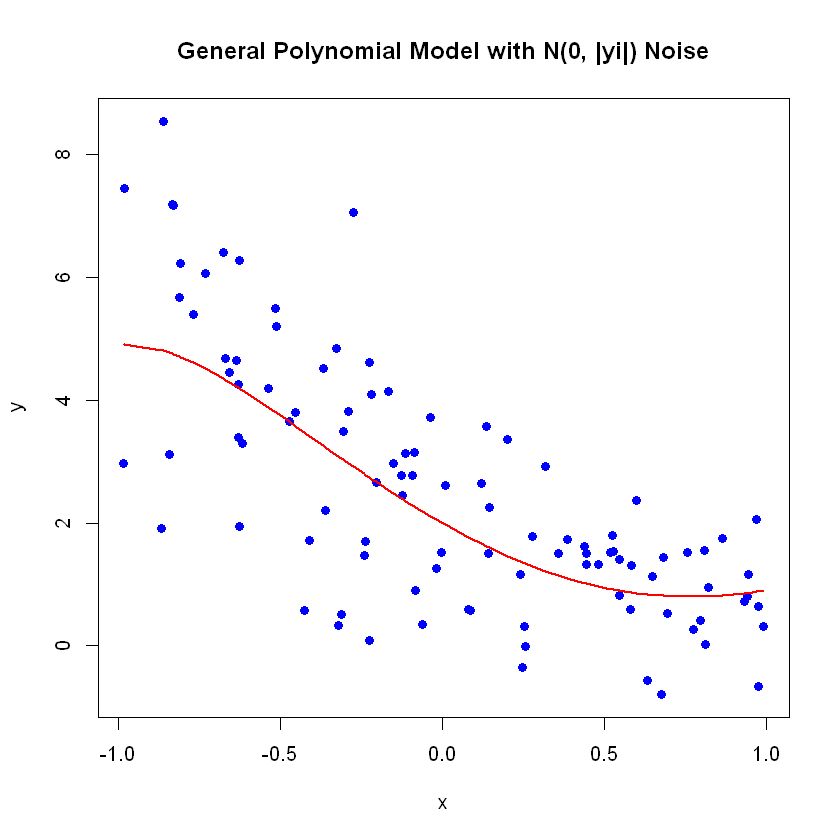

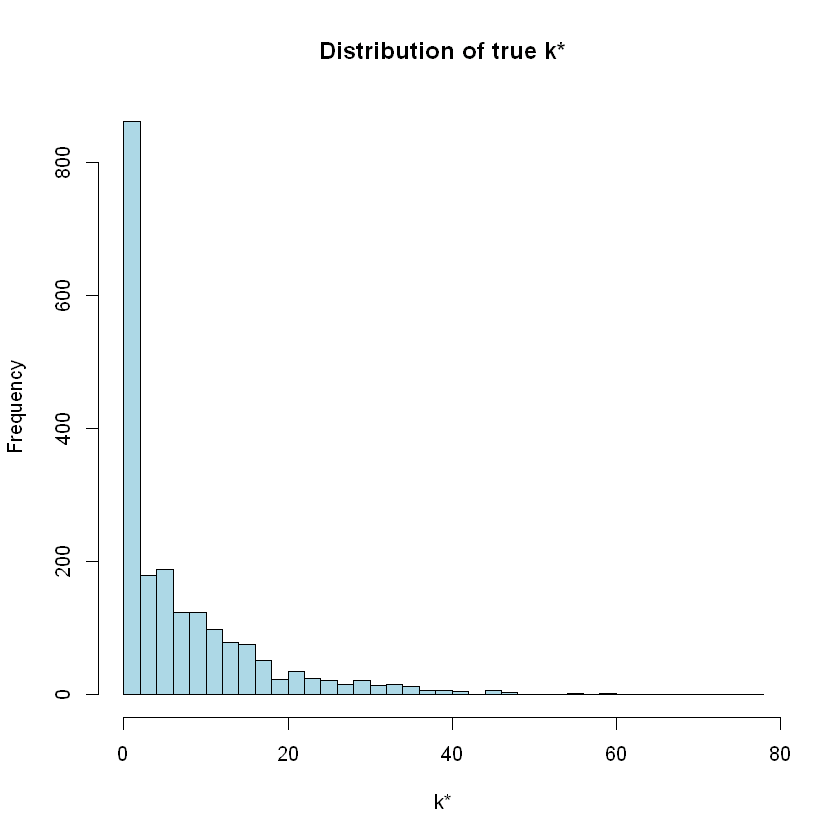

Total meta rows built: 2000 

Meta-train rows: 1600 
Meta-test rows : 400 

Mean CV RMSE raw: 11.43934 
Mean CV RMSE int: 11.07565 

Final Test RMSE raw: 9.908639 
Final Test RMSE int: 9.475495 
Final Test MAE int: 6.78 


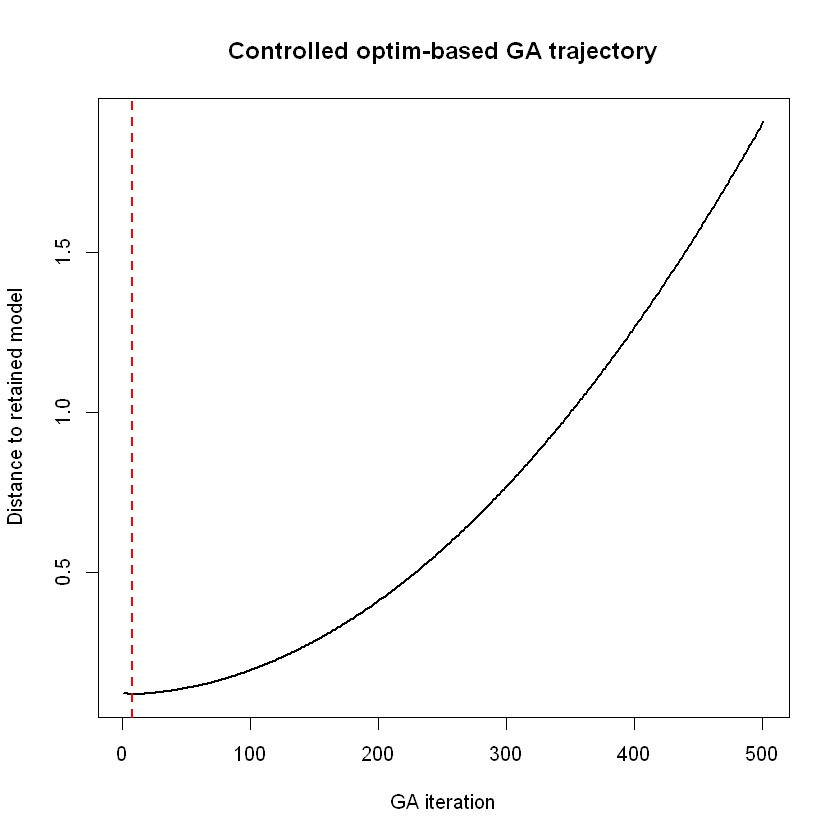

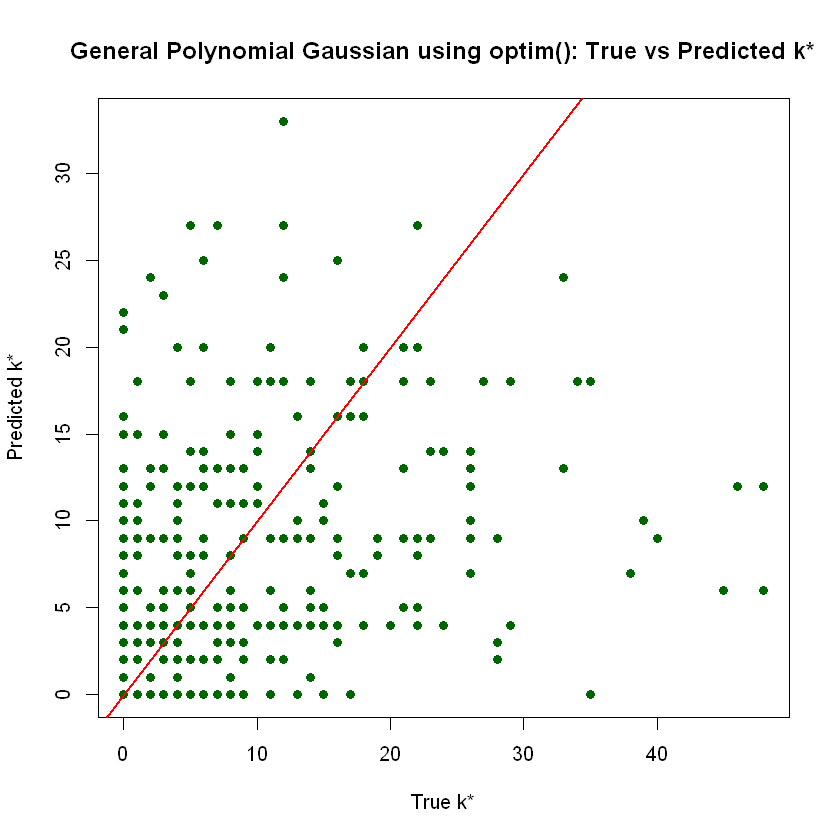

In [6]:

# GENERAL POLYNOMIAL MODEL USING optim()

# y = w0 + w1*x + w2*x^2 + ... + w_(d-1)*x^(d-1) + e
# e ~ N(0, |yi|)

# Controlled GA:
# optim() + L-BFGS-B
# T_GA = 500
# step_size = 0.001


set.seed(42)

if (!require(nnet)) {
  install.packages("nnet", repos = "https://cloud.r-project.org")
}
library(nnet)

safe_sd <- function(x) {
  if (length(x) <= 1) return(0)
  s <- sd(x)
  if (is.na(s) || is.nan(s) || is.infinite(s)) return(0)
  s
}

make_poly_design <- function(x, degree_terms = 5) {
  Phi <- sapply(0:(degree_terms - 1), function(k) x^k)
  colnames(Phi) <- paste0("x_power_", 0:(degree_terms - 1))
  as.matrix(Phi)
}

simulate_polynomial_gaussian_yi <- function(
    n = 100,
    degree_terms = 5,
    theta_true = c(2, -3, 1.5, 0.7, -0.4),
    x_min = -1,
    x_max = 1,
    min_sd = 0.001,
    seed = NULL
) {
  if (!is.null(seed)) set.seed(seed)

  if (length(theta_true) != degree_terms) {
    stop("theta_true length must match degree_terms")
  }

  x <- runif(n, x_min, x_max)

  Phi <- make_poly_design(x, degree_terms)

  y_true <- as.vector(Phi %*% theta_true)

  sigma_i <- sqrt(pmax(abs(y_true), min_sd))

  eps <- rnorm(
    n = n,
    mean = 0,
    sd = sigma_i
  )

  y_obs <- y_true + eps

  data.frame(
    x = x,
    y = y_obs,
    y_true = y_true,
    sigma_i = sigma_i
  )
}

standardize_xy <- function(x, y) {
  x_sd <- safe_sd(x)
  y_sd <- safe_sd(y)

  if (x_sd == 0) x_sd <- 1
  if (y_sd == 0) y_sd <- 1

  list(
    x = (x - mean(x)) / x_sd,
    y = (y - mean(y)) / y_sd
  )
}

mse_loss <- function(theta, Phi, Y) {
  pred <- as.vector(Phi %*% theta)
  mean((Y - pred)^2)
}

fit_optim_gd <- function(Phi, Y, theta_init = NULL, maxit = 1000) {
  if (is.null(theta_init)) {
    theta_init <- rep(0, ncol(Phi))
  }

  fit <- optim(
    par = theta_init,
    fn = mse_loss,
    Phi = Phi,
    Y = Y,
    method = "BFGS",
    control = list(maxit = maxit)
  )

  fit$par
}

ga_trajectory_optim <- function(
    theta_start,
    Phi_del,
    Y_del,
    T_GA = 500,
    step_size = 0.001
) {
  theta_now <- theta_start

  traj_theta <- matrix(
    NA,
    nrow = T_GA + 1,
    ncol = length(theta_start)
  )

  traj_theta[1, ] <- theta_now

  for (k in 1:T_GA) {
    fit <- optim(
      par = theta_now,
      fn = function(theta) {
        -mse_loss(theta, Phi_del, Y_del)
      },
      method = "L-BFGS-B",
      lower = theta_now - step_size,
      upper = theta_now + step_size,
      control = list(maxit = 1)
    )

    theta_now <- fit$par
    traj_theta[k + 1, ] <- theta_now
  }

  traj_theta
}

one_experiment_deleted_retained <- function(
    df,
    p_del,
    degree_terms = 7,
    T_GD = 1000,
    T_GA = 500,
    step_size = 0.001
) {
  x <- df$x
  y <- df$y
  n <- nrow(df)

  K_del <- max(1, floor(n * p_del))
  K_del <- min(K_del, n - 1)

  st <- standardize_xy(x, y)

  X <- st$x
  Y <- st$y

  Phi <- make_poly_design(X, degree_terms)

  theta_full <- fit_optim_gd(
    Phi = Phi,
    Y = Y,
    maxit = T_GD
  )

  del_idx <- sample(1:n, K_del, replace = FALSE)

  del_mask <- rep(FALSE, n)
  del_mask[del_idx] <- TRUE

  Phi_del <- Phi[del_mask, , drop = FALSE]
  Y_del <- Y[del_mask]

  Phi_ret <- Phi[!del_mask, , drop = FALSE]
  Y_ret <- Y[!del_mask]

  theta_ret <- fit_optim_gd(
    Phi = Phi_ret,
    Y = Y_ret,
    maxit = T_GD
  )

  traj_theta <- ga_trajectory_optim(
    theta_start = theta_full,
    Phi_del = Phi_del,
    Y_del = Y_del,
    T_GA = T_GA,
    step_size = step_size
  )

  dists <- rowSums(
    sweep(traj_theta, 2, theta_ret, "-")^2
  )

  k_star <- which.min(dists) - 1

  deleted_points <- as.matrix(df[del_mask, c("x", "y")])
  retained_points <- as.matrix(df[!del_mask, c("x", "y")])

  deleted_points <- deleted_points[order(deleted_points[, 1]), , drop = FALSE]
  retained_points <- retained_points[order(retained_points[, 1]), , drop = FALSE]

  list(
    deleted_points = deleted_points,
    retained_points = retained_points,
    k_star = as.numeric(k_star),
    K_del = K_del,
    p_del = p_del,
    dists = dists,
    theta_full = theta_full,
    theta_ret = theta_ret,
    traj_theta = traj_theta
  )
}

build_experiment_dataset <- function(
    df,
    n_experiments = 2000,
    degree_terms = 7,
    p_min = 0.01,
    p_max = 0.50,
    T_GD = 1000,
    T_GA = 500,
    step_size = 0.001
) {
  samples <- vector("list", n_experiments)

  for (i in 1:n_experiments) {
    p_now <- runif(1, min = p_min, max = p_max)

    samples[[i]] <- one_experiment_deleted_retained(
      df = df,
      p_del = p_now,
      degree_terms = degree_terms,
      T_GD = T_GD,
      T_GA = T_GA,
      step_size = step_size
    )

    if (i %% 200 == 0) {
      cat("Generated", i, "experiments\n")
    }
  }

  samples
}

embed_and_pool <- function(points_mat, W, b) {
  if (nrow(points_mat) == 0) {
    stop("Empty point set")
  }

  embedded <- sweep(points_mat %*% W, 2, b, "+")

  mean_pool <- colMeans(embedded)
  max_pool  <- apply(embedded, 2, max)
  min_pool  <- apply(embedded, 2, min)
  sd_pool   <- apply(embedded, 2, safe_sd)

  c(mean_pool, max_pool, min_pool, sd_pool)
}

build_pooled_feature_table <- function(
    samples,
    embed_dim = 16,
    total_raw_n = 100,
    seed = 42
) {
  set.seed(seed)

  W <- matrix(
    rnorm(2 * embed_dim, mean = 0, sd = 0.3),
    nrow = 2,
    ncol = embed_dim
  )

  b <- rnorm(embed_dim, mean = 0, sd = 0.05)

  rows <- vector("list", length(samples))

  for (i in seq_along(samples)) {
    s <- samples[[i]]

    del_vec <- embed_and_pool(s$deleted_points, W, b)
    ret_vec <- embed_and_pool(s$retained_points, W, b)

    row_i <- as.data.frame(as.list(c(del_vec, ret_vec)))

    names(row_i) <- c(
      paste0("del_mean_emb_", 1:embed_dim),
      paste0("del_max_emb_", 1:embed_dim),
      paste0("del_min_emb_", 1:embed_dim),
      paste0("del_sd_emb_", 1:embed_dim),
      paste0("ret_mean_emb_", 1:embed_dim),
      paste0("ret_max_emb_", 1:embed_dim),
      paste0("ret_min_emb_", 1:embed_dim),
      paste0("ret_sd_emb_", 1:embed_dim)
    )

    row_i$p_del <- s$p_del
    row_i$K_del <- s$K_del
    row_i$del_fraction <- s$K_del / total_raw_n
    row_i$target_k_star <- s$k_star

    rows[[i]] <- row_i
  }

  na.omit(do.call(rbind, rows))
}

scale_features_train <- function(df_features) {
  means <- sapply(df_features, mean)
  sds <- sapply(df_features, safe_sd)
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  list(data = scaled, means = means, sds = sds)
}

scale_features_apply <- function(df_features, means, sds) {
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  scaled
}

fit_best_nnet <- function(
    x_train_sc,
    y_train,
    hidden_units = 8,
    decay = 0.001,
    maxit = 1500,
    maxnwts = 20000,
    n_repeats = 5,
    seed = 42
) {
  best_fit <- NULL
  best_sse <- Inf

  for (r in 1:n_repeats) {
    set.seed(seed + r)

    fit_try <- try(
      nnet(
        x = x_train_sc,
        y = y_train,
        size = hidden_units,
        linout = TRUE,
        decay = decay,
        maxit = maxit,
        trace = FALSE,
        MaxNWts = maxnwts
      ),
      silent = TRUE
    )

    if (inherits(fit_try, "try-error")) next

    pred_train <- as.numeric(predict(fit_try, x_train_sc))
    sse <- sum((pred_train - y_train)^2)

    if (is.finite(sse) && sse < best_sse) {
      best_sse <- sse
      best_fit <- fit_try
    }
  }

  if (is.null(best_fit)) stop("All MLP fits failed.")
  best_fit
}

postprocess_khat <- function(pred_scaled, target_mean, target_sd, T_GA) {
  pred_raw <- pred_scaled * target_sd + target_mean
  pred_int <- round(pred_raw)
  pred_int <- pmax(0, pmin(T_GA, pred_int))

  list(pred_raw = pred_raw, pred_int = pred_int)
}

cv_mlp_regression <- function(
    meta_train,
    k_folds = 5,
    hidden_units = 8,
    T_GA = 500,
    seed = 42
) {
  set.seed(seed)

  n <- nrow(meta_train)
  fold_id <- sample(rep(1:k_folds, length.out = n))

  rmse_raw_vec <- c()
  rmse_int_vec <- c()

  feature_names <- setdiff(names(meta_train), "target_k_star")

  for (fold in 1:k_folds) {
    train_fold <- meta_train[fold_id != fold, ]
    valid_fold <- meta_train[fold_id == fold, ]

    x_train <- train_fold[, feature_names, drop = FALSE]
    y_train_raw <- train_fold$target_k_star

    x_valid <- valid_fold[, feature_names, drop = FALSE]
    y_valid <- valid_fold$target_k_star

    y_mean_fold <- mean(y_train_raw)
    y_sd_fold <- safe_sd(y_train_raw)

    if (y_sd_fold == 0) {
      y_sd_fold <- 1
    }

    y_train <- (y_train_raw - y_mean_fold) / y_sd_fold

    sc <- scale_features_train(x_train)

    x_train_sc <- as.matrix(sc$data)
    x_valid_sc <- as.matrix(
      scale_features_apply(x_valid, sc$means, sc$sds)
    )

    mlp_fit <- fit_best_nnet(
      x_train_sc = x_train_sc,
      y_train = y_train,
      hidden_units = hidden_units,
      seed = seed + 100 * fold
    )

    pred_scaled <- as.numeric(predict(mlp_fit, x_valid_sc))

    pred_out <- postprocess_khat(
      pred_scaled = pred_scaled,
      target_mean = y_mean_fold,
      target_sd = y_sd_fold,
      T_GA = T_GA
    )

    rmse_raw <- sqrt(mean((pred_out$pred_raw - y_valid)^2))
    rmse_int <- sqrt(mean((pred_out$pred_int - y_valid)^2))

    rmse_raw_vec <- c(rmse_raw_vec, rmse_raw)
    rmse_int_vec <- c(rmse_int_vec, rmse_int)
  }

  list(
    mean_rmse_raw = mean(rmse_raw_vec),
    mean_rmse_int = mean(rmse_int_vec)
  )
}

train_and_test_mlp <- function(
    meta_train,
    meta_test,
    hidden_units = 8,
    T_GA = 500,
    seed = 42
) {
  feature_names <- setdiff(names(meta_train), "target_k_star")

  target_mean <- mean(meta_train$target_k_star)
  target_sd <- safe_sd(meta_train$target_k_star)

  if (target_sd == 0) {
    target_sd <- 1
  }

  x_train <- meta_train[, feature_names, drop = FALSE]
  x_test <- meta_test[, feature_names, drop = FALSE]

  y_train_scaled <- (meta_train$target_k_star - target_mean) / target_sd
  y_test <- meta_test$target_k_star

  sc <- scale_features_train(x_train)

  x_train_sc <- as.matrix(sc$data)
  x_test_sc <- as.matrix(
    scale_features_apply(x_test, sc$means, sc$sds)
  )

  final_mlp <- fit_best_nnet(
    x_train_sc = x_train_sc,
    y_train = y_train_scaled,
    hidden_units = hidden_units,
    seed = seed
  )

  pred_scaled <- as.numeric(predict(final_mlp, x_test_sc))

  pred_out <- postprocess_khat(
    pred_scaled = pred_scaled,
    target_mean = target_mean,
    target_sd = target_sd,
    T_GA = T_GA
  )

  rmse_raw <- sqrt(mean((pred_out$pred_raw - y_test)^2))
  rmse_int <- sqrt(mean((pred_out$pred_int - y_test)^2))
  mae_int <- mean(abs(pred_out$pred_int - y_test))

  list(
    y_test = y_test,
    pred_int = pred_out$pred_int,
    rmse_raw = rmse_raw,
    rmse_int = rmse_int,
    mae_int = mae_int
  )
}

# MAIN
degree_terms <- 7

theta_true <- c(
  2,
  -3,
  1.5,
  0.7,
  -0.4,
  0.3,
  -0.2
)
base_df <- simulate_polynomial_gaussian_yi(
  n = 100,
  degree_terms = degree_terms,
  theta_true = theta_true,
  x_min = -1,
  x_max = 1,
  seed = 7
)

cat("GENERAL POLYNOMIAL FEATURE MODEL USING optim()\n")
cat("Model: y = w0 + w1*x + ... + w_(d-1)*x^(d-1) + e\n")
cat("Noise: e ~ N(0, |yi|)\n")
cat("Degree terms:", degree_terms, "\n")
cat("Total raw points:", nrow(base_df), "\n\n")

plot(
  base_df$x,
  base_df$y,
  pch = 16,
  col = "blue",
  xlab = "x",
  ylab = "y",
  main = "General Polynomial Model with N(0, |yi|) Noise"
)

ord <- order(base_df$x)
lines(base_df$x[ord], base_df$y_true[ord], col = "red", lwd = 2)

samples <- build_experiment_dataset(
  df = base_df,
  n_experiments = 2000,
  degree_terms = degree_terms,
  T_GA = 500,
  step_size = 0.001
)

cat("Total experiments built:", length(samples), "\n\n")

kstars <- sapply(samples, function(s) s$k_star)

cat("Summary of true k*:\n")
print(summary(kstars))

hist(
  kstars,
  breaks = 40,
  col = "lightblue",
  main = "Distribution of true k*",
  xlab = "k*"
)

plot(
  samples[[1]]$dists,
  type = "l",
  lwd = 2,
  xlab = "GA iteration",
  ylab = "Distance to retained model",
  main = "Controlled optim-based GA trajectory"
)

abline(
  v = samples[[1]]$k_star + 1,
  col = "red",
  lwd = 2,
  lty = 2
)

meta_all <- build_pooled_feature_table(
  samples = samples,
  embed_dim = 16,
  total_raw_n = nrow(base_df),
  seed = 42
)

cat("Total meta rows built:", nrow(meta_all), "\n\n")

set.seed(42)

idx_meta_train <- sample(
  seq_len(nrow(meta_all)),
  size = floor(0.8 * nrow(meta_all))
)

meta_train <- meta_all[idx_meta_train, ]
meta_test <- meta_all[-idx_meta_train, ]

cat("Meta-train rows:", nrow(meta_train), "\n")
cat("Meta-test rows :", nrow(meta_test), "\n\n")

cv_res <- cv_mlp_regression(
  meta_train = meta_train,
  hidden_units = 8,
  T_GA = 500
)

cat("Mean CV RMSE raw:", cv_res$mean_rmse_raw, "\n")
cat("Mean CV RMSE int:", cv_res$mean_rmse_int, "\n\n")

final_res <- train_and_test_mlp(
  meta_train = meta_train,
  meta_test = meta_test,
  hidden_units = 8,
  T_GA = 500
)

cat("Final Test RMSE raw:", final_res$rmse_raw, "\n")
cat("Final Test RMSE int:", final_res$rmse_int, "\n")
cat("Final Test MAE int:", final_res$mae_int, "\n")

plot(
  final_res$y_test,
  final_res$pred_int,
  pch = 16,
  col = "darkgreen",
  xlab = "True k*",
  ylab = "Predicted k*",
  main = "General Polynomial Gaussian using optim(): True vs Predicted k*"
)

abline(0, 1, col = "red", lwd = 2)